# KNHANES 2021–2024: 단일 EPF의 수치·분류 공동 학습

19–39세의 비침습적 대사이상 선별이라는 원래 주제만 다룬다. 실제 혈당·혈압·TG·HDL은 **정답에만** 사용했다. 아래는 완료한 실험의 집계 재계산이며 원자료 재학습 노트북은 아니다.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
R=json.loads('{"version": "clinical_multitask_v18", "n": 4068, "years": {"2021": 1039, "2022": 1013, "2023": 1010, "2024": 1006}, "models": {"EPF_classification": {"clean": {"macro_ap": 0.35985096273763056, "macro_auc": 0.7756301760805426, "macro_brier": 0.10654676197955622, "macro_NLL": 0.34823872933925104, "per_label": [{"ap": 0.3673772617050975, "auc": 0.7936297059020064, "brier": 0.09619014346188022}, {"ap": 0.2636338990324687, "auc": 0.7579189422926663, "brier": 0.08384578761224458}, {"ap": 0.4352508052634989, "auc": 0.8001566119512856, "brier": 0.1254874460395191}, {"ap": 0.37314188494945705, "auc": 0.7508154441762119, "brier": 0.12066367080458103}]}, "missing20": {"macro_ap": 0.3438550410468641, "macro_auc": 0.7595486758019945, "macro_brier": 0.10854723257562959, "macro_NLL": 0.35612916107245557, "per_label": [{"ap": 0.3468876874182917, "auc": 0.7822464464988266, "brier": 0.09788877475766505}, {"ap": 0.25348373972574584, "auc": 0.7477083107849963, "brier": 0.08425168353636484}, {"ap": 0.4197335420074196, "auc": 0.7814833574020223, "brier": 0.12881920688329965}, {"ap": 0.35531519503599923, "auc": 0.7267565885221324, "brier": 0.12322926512518888}]}, "per_seed": [{"seed": 42, "clean": {"macro_ap": 0.3602689509046598, "macro_auc": 0.7759522528097749, "macro_brier": 0.10652171532555618, "macro_NLL": 0.3482053530544891, "per_label": [{"ap": 0.36501931086287404, "auc": 0.7933457984873842, "brier": 0.09631392061852864}, {"ap": 0.26182476099286134, "auc": 0.7587693246278987, "brier": 0.08402335496052027}, {"ap": 0.43837195962261527, "auc": 0.8001957091486702, "brier": 0.1252962970417386}, {"ap": 0.3758597721402889, "auc": 0.7514981789751465, "brier": 0.12045328868143726}]}, "missing20": {"macro_ap": 0.3445373354287577, "macro_auc": 0.7595738734447611, "macro_brier": 0.10851190547995333, "macro_NLL": 0.3560918563585896, "per_label": [{"ap": 0.3465021704830584, "auc": 0.7819632136328424, "brier": 0.09793247026635367}, {"ap": 0.251932454593494, "auc": 0.748209121058717, "brier": 0.08431625721202511}, {"ap": 0.4212125145048717, "auc": 0.781076584663039, "brier": 0.12876259648984642}, {"ap": 0.35850220213360684, "auc": 0.727046574424446, "brier": 0.12303629795158817}]}}, {"seed": 43, "clean": {"macro_ap": 0.35870102389114566, "macro_auc": 0.7751477839611726, "macro_brier": 0.10663061592273264, "macro_NLL": 0.34843756727746517, "per_label": [{"ap": 0.3665642839312483, "auc": 0.7931499604613669, "brier": 0.09624844251588087}, {"ap": 0.2659763982239008, "auc": 0.7574542435811438, "brier": 0.08362965988416143}, {"ap": 0.43119248668039756, "auc": 0.7998337174832069, "brier": 0.12578545702314825}, {"ap": 0.37107092672903597, "auc": 0.7501532143189729, "brier": 0.12085890426773997}]}, "missing20": {"macro_ap": 0.3442034852137388, "macro_auc": 0.7598891076238724, "macro_brier": 0.10852988389684402, "macro_NLL": 0.35604601809552294, "per_label": [{"ap": 0.3480319259683302, "auc": 0.7818816733003007, "brier": 0.09785592314455882}, {"ap": 0.25513012559424997, "auc": 0.7482193863946858, "brier": 0.08419187686091208}, {"ap": 0.41884901006485403, "auc": 0.7821573223643089, "brier": 0.12880812639995232}, {"ap": 0.354802879227521, "auc": 0.7272980484361943, "brier": 0.1232636091819528}]}}, {"seed": 44, "clean": {"macro_ap": 0.36058291341708615, "macro_auc": 0.7757904914706802, "macro_brier": 0.10648795469037989, "macro_NLL": 0.3480732676857989, "per_label": [{"ap": 0.37054819032117026, "auc": 0.7943933587572681, "brier": 0.09600806725123115}, {"ap": 0.26310053788064386, "auc": 0.7575332586689564, "brier": 0.08388434799205202}, {"ap": 0.436187969487484, "auc": 0.8004404092219799, "brier": 0.1253805840536705}, {"ap": 0.37249495597904636, "auc": 0.7507949392345162, "brier": 0.12067881946456589}]}, "missing20": {"macro_ap": 0.34282430249809576, "macro_auc": 0.7591830463373497, "macro_brier": 0.10859990835009144, "macro_NLL": 0.35624960876325423, "per_label": [{"ap": 0.34612896580348657, "auc": 0.7828944525633365, "brier": 0.0978779308620827}, {"ap": 0.2533886389894935, "auc": 0.7466964249015864, "brier": 0.0842469165361573}, {"ap": 0.419139101452533, "auc": 0.781216165178719, "brier": 0.12888689776010018}, {"ap": 0.3526405037468699, "auc": 0.7259251427057568, "brier": 0.12338788824202562}]}}], "screening": {"0.9": {"sensitivity": 0.8721990498207899, "specificity": 0.4718764527407883, "referral_rate": 0.6588456249612377}, "0.95": {"sensitivity": 0.9319221994064226, "specificity": 0.3220009943421313, "referral_rate": 0.774470179038207}}, "descriptive_matched_sensitivity": {"0.9": {"specificity": 0.4082388742967269, "referral_rate": 0.7088680565269532, "note": "Interpolated held-out ROC comparison only, not a deployable test-selected cutoff"}, "0.95": {"specificity": 0.29643447909494597, "referral_rate": 0.7971915619480151, "note": "Interpolated held-out ROC comparison only, not a deployable test-selected cutoff"}}, "stress": {"missing10": {"macro_ap": 0.3548401628387023, "macro_auc": 0.7668306840388435, "macro_brier": 0.10745967800342938, "macro_NLL": 0.3521155958481961, "per_label": [{"ap": 0.35491729910285724, "auc": 0.78510118859357, "brier": 0.09723359654016968}, {"ap": 0.2800712833381087, "auc": 0.7554407596076821, "brier": 0.0828466862229692}, {"ap": 0.42794338199227583, "auc": 0.793088576915789, "brier": 0.12700260315731074}, {"ap": 0.3564286869215674, "auc": 0.7336922110383329, "brier": 0.1227558260932679}]}, "missing30": {"macro_ap": 0.3321735287563689, "macro_auc": 0.7495420224101857, "macro_brier": 0.10990699804466005, "macro_NLL": 0.36088084463151476, "per_label": [{"ap": 0.32140444172788585, "auc": 0.7589029627140369, "brier": 0.1004776859101041}, {"ap": 0.2383844322665463, "auc": 0.7504885799623368, "brier": 0.08484387254158686}, {"ap": 0.4176198255808557, "auc": 0.7735321608467887, "brier": 0.13008756399115587}, {"ap": 0.3512854154501876, "auc": 0.7152443861175803, "brier": 0.12421886973579337}]}, "missing40": {"macro_ap": 0.31453151988772404, "macro_auc": 0.7366819347650195, "macro_brier": 0.11172663906642612, "macro_NLL": 0.3673955986849267, "per_label": [{"ap": 0.32396473064229175, "auc": 0.7584078372625619, "brier": 0.10006929219521521}, {"ap": 0.22415792675891533, "auc": 0.7405529973886121, "brier": 0.08591486899003699}, {"ap": 0.38633952514559305, "auc": 0.7518302759087042, "brier": 0.13411682633636926}, {"ap": 0.323663897004096, "auc": 0.6959366285002001, "brier": 0.12680556874408305}]}, "body_missing": {"macro_ap": 0.24826317007749368, "macro_auc": 0.6723409815363622, "macro_brier": 0.11749811482374789, "macro_NLL": 0.38864674919787, "per_label": [{"ap": 0.23841384355565032, "auc": 0.6846621353796457, "brier": 0.10701752509992406}, {"ap": 0.19523815109256945, "auc": 0.6927864077074966, "brier": 0.08705220953938575}, {"ap": 0.3313346738790715, "auc": 0.6970189532873649, "brier": 0.1415934799514696}, {"ap": 0.2280660117826834, "auc": 0.6148964297709417, "brier": 0.13432924470421215}]}, "behavior_missing": {"macro_ap": 0.3455114122046831, "macro_auc": 0.7677383253859208, "macro_brier": 0.10834770999352379, "macro_NLL": 0.35410221598351077, "per_label": [{"ap": 0.3550513802799274, "auc": 0.7921918144737323, "brier": 0.09711276637337106}, {"ap": 0.2641033172963131, "auc": 0.7617560926095063, "brier": 0.08501306381005591}, {"ap": 0.43161301366388766, "auc": 0.7970549306219924, "brier": 0.12605831883405694}, {"ap": 0.3312779375786044, "auc": 0.7199504638384518, "brier": 0.12520669095661133}]}, "BMI_noise10": {"macro_ap": 0.3595709837196222, "macro_auc": 0.775301791324662, "macro_brier": 0.10656999081007547, "macro_NLL": 0.34839615615956704, "per_label": [{"ap": 0.36640803346802137, "auc": 0.7929982236636067, "brier": 0.09627904883975258}, {"ap": 0.2629718599754604, "auc": 0.7572011843423931, "brier": 0.08391113284603328}, {"ap": 0.4358170945340623, "auc": 0.8000296108067543, "brier": 0.12546089183799114}, {"ap": 0.373086946900945, "auc": 0.7509781464858944, "brier": 0.12062888971652491}]}, "BMI_noise25": {"macro_ap": 0.35749180949390064, "macro_auc": 0.7753196488494943, "macro_brier": 0.10672873546109511, "macro_NLL": 0.34869104886090696, "per_label": [{"ap": 0.36427334074945444, "auc": 0.7927964497232495, "brier": 0.0963792548602614}, {"ap": 0.26132682388236605, "auc": 0.7590104252820055, "brier": 0.08399050920629066}, {"ap": 0.43406251901756226, "auc": 0.7995339990143032, "brier": 0.12564911643674795}, {"ap": 0.3703045543262197, "auc": 0.749937721378419, "brier": 0.12089606134108043}]}, "WC_noise10": {"macro_ap": 0.3598577630526218, "macro_auc": 0.7750668658971289, "macro_brier": 0.10657357045598441, "macro_NLL": 0.34844122977336744, "per_label": [{"ap": 0.36718862848017375, "auc": 0.7932703650131327, "brier": 0.09616868755282344}, {"ap": 0.2631458943270491, "auc": 0.757974527602696, "brier": 0.08385862521517484}, {"ap": 0.4349988990024245, "auc": 0.7994824595510995, "brier": 0.12560980328298765}, {"ap": 0.3740976304008397, "auc": 0.7495401114215876, "brier": 0.12065716577295167}]}, "WC_noise25": {"macro_ap": 0.3564728283457015, "macro_auc": 0.772689807838641, "macro_brier": 0.10702583923082304, "macro_NLL": 0.3499747370915145, "per_label": [{"ap": 0.36348908329565993, "auc": 0.7899672629644278, "brier": 0.0965893611840508}, {"ap": 0.2642119106515113, "auc": 0.7598681600893329, "brier": 0.08376894334731792}, {"ap": 0.43066666498097184, "auc": 0.7968460828627589, "brier": 0.12626499316990483}, {"ap": 0.36752365445466295, "auc": 0.744077725438045, "brier": 0.12148005922201861}]}}}, "EPF_regression": {"clean": {"macro_ap": 0.36463295192078443, "macro_auc": 0.7733566035554537, "macro_brier": 0.10637306380018173, "macro_NLL": 0.3499128770446665, "per_label": [{"ap": 0.35664220833079247, "auc": 0.7704945775703723, "brier": 0.09825242708376485}, {"ap": 0.2679441122758522, "auc": 0.7700535446268219, "brier": 0.08286033204144012}, {"ap": 0.4536015353103704, "auc": 0.8050087398821866, "brier": 0.12367511679379663}, {"ap": 0.38034395176612246, "auc": 0.7478695521424337, "brier": 0.12070437928172532}]}, "missing20": {"macro_ap": 0.34476246131151184, "macro_auc": 0.7538041926694027, "macro_brier": 0.10888226697421036, "macro_NLL": 0.3588722069366504, "per_label": [{"ap": 0.3319830879377729, "auc": 0.7521615167198147, "brier": 0.10023910416138442}, {"ap": 0.2594694138964432, "auc": 0.7580599252309546, "brier": 0.0834236862967311}, {"ap": 0.4321615051240044, "auc": 0.7842794989081622, "brier": 0.12802170154059578}, {"ap": 0.3554358382878269, "auc": 0.7207158298186795, "brier": 0.12384457589813014}]}, "per_seed": [{"seed": 42, "clean": {"macro_ap": 0.3662621418506965, "macro_auc": 0.774148430967008, "macro_brier": 0.10625681263174529, "macro_NLL": 0.3495465729650242, "per_label": [{"ap": 0.35922584986021994, "auc": 0.7722840532716326, "brier": 0.09806901360167027}, {"ap": 0.26826417955143633, "auc": 0.7711713532855593, "brier": 0.08280830804476029}, {"ap": 0.4543325664958155, "auc": 0.8053820862761244, "brier": 0.12356816319327305}, {"ap": 0.383225971495314, "auc": 0.7477562310347157, "brier": 0.12058176568727758}]}, "missing20": {"macro_ap": 0.34593726308348044, "macro_auc": 0.7547127988781254, "macro_brier": 0.10879258140289488, "macro_NLL": 0.3586092664855598, "per_label": [{"ap": 0.33310095593718225, "auc": 0.7539762628557871, "brier": 0.10013538549933641}, {"ap": 0.2588910097559628, "auc": 0.7589066751016126, "brier": 0.08340456460134209}, {"ap": 0.4337242620519433, "auc": 0.7851973079127718, "brier": 0.12786662359396148}, {"ap": 0.3580328245888334, "auc": 0.72077094964233, "brier": 0.12376375191693957}]}}, {"seed": 43, "clean": {"macro_ap": 0.3648815002205277, "macro_auc": 0.7723767152642367, "macro_brier": 0.10643892191785764, "macro_NLL": 0.35025756132226904, "per_label": [{"ap": 0.35810068639408, "auc": 0.7677640456820428, "brier": 0.09831870323081368}, {"ap": 0.2700490108091521, "auc": 0.7695364324425809, "brier": 0.08280604812502551}, {"ap": 0.45186558470956556, "auc": 0.8040360610015209, "brier": 0.12395570999364651}, {"ap": 0.379510718969313, "auc": 0.7481703219308022, "brier": 0.1206752263219449}]}, "missing20": {"macro_ap": 0.343424051670884, "macro_auc": 0.7522973645269287, "macro_brier": 0.10901760478577523, "macro_NLL": 0.3594001757640122, "per_label": [{"ap": 0.3330489037989139, "auc": 0.7486096915410464, "brier": 0.10034298824376585}, {"ap": 0.2585291816709273, "auc": 0.7574751874355609, "brier": 0.08344861937294233}, {"ap": 0.4293814227010275, "auc": 0.7826627472035882, "brier": 0.1283077542907206}, {"ap": 0.35273669851266726, "auc": 0.7204418319275199, "brier": 0.12397105723567209}]}}, {"seed": 44, "clean": {"macro_ap": 0.36275521369112895, "macro_auc": 0.773544664435116, "macro_brier": 0.10642345685094223, "macro_NLL": 0.3499344968467063, "per_label": [{"ap": 0.3526000887380773, "auc": 0.7714356337574415, "brier": 0.09836956441881053}, {"ap": 0.26551914646696806, "auc": 0.7694528481523254, "brier": 0.08296663995453459}, {"ap": 0.45460645472573014, "auc": 0.8056080723689142, "brier": 0.12350147719447034}, {"ap": 0.37829516483374037, "auc": 0.7476821034617829, "brier": 0.12085614583595347}]}, "missing20": {"macro_ap": 0.34492606918017105, "macro_auc": 0.7544024146031543, "macro_brier": 0.10883661473396095, "macro_NLL": 0.3586071785603793, "per_label": [{"ap": 0.3297994040772226, "auc": 0.7538985957626104, "brier": 0.10023893874105098}, {"ap": 0.26098805026243943, "auc": 0.7577979131556903, "brier": 0.0834178749159089}, {"ap": 0.43337883061904225, "auc": 0.7849784416081267, "brier": 0.1278907267371052}, {"ap": 0.3555379917619799, "auc": 0.7209347078861889, "brier": 0.12379891854177875}]}}], "screening": {"0.9": {"sensitivity": 0.865551914838267, "specificity": 0.4820075245801938, "referral_rate": 0.6500381796547406}, "0.95": {"sensitivity": 0.9325115732868335, "specificity": 0.29416833028013095, "referral_rate": 0.7919525000229951}}, "descriptive_matched_sensitivity": {"0.9": {"specificity": 0.38416065101130853, "referral_rate": 0.7237984173466911, "note": "Interpolated held-out ROC comparison only, not a deployable test-selected cutoff"}, "0.95": {"specificity": 0.24546967247593746, "referral_rate": 0.8287936840361003, "note": "Interpolated held-out ROC comparison only, not a deployable test-selected cutoff"}}, "stress": {"missing10": {"macro_ap": 0.35562016813462344, "macro_auc": 0.7645323793381568, "macro_brier": 0.1076154595670622, "macro_NLL": 0.354323184342255, "per_label": [{"ap": 0.34425475199038047, "auc": 0.761071764139906, "brier": 0.09929654776598702}, {"ap": 0.274279402609462, "auc": 0.7680226735112381, "brier": 0.08245793677065665}, {"ap": 0.4388973225290009, "auc": 0.7976407985414552, "brier": 0.12606257272837199}, {"ap": 0.36504919540965036, "auc": 0.731394281160028, "brier": 0.1226447810032331}]}, "missing30": {"macro_ap": 0.33021323066949465, "macro_auc": 0.7464649699762864, "macro_brier": 0.110117616337346, "macro_NLL": 0.36271312847876414, "per_label": [{"ap": 0.3004413376762738, "auc": 0.7393675460126542, "brier": 0.10228013426079446}, {"ap": 0.24191808309211763, "auc": 0.7566813173493824, "brier": 0.08423937406174507}, {"ap": 0.43470842398378257, "auc": 0.7817979810751442, "brier": 0.1287037443512651}, {"ap": 0.34378507792580465, "auc": 0.7080130354679645, "brier": 0.12524721267557942}]}, "missing40": {"macro_ap": 0.3093400190424193, "macro_auc": 0.7299391258200609, "macro_brier": 0.1122519425587734, "macro_NLL": 0.3696678307613402, "per_label": [{"ap": 0.300533679535648, "auc": 0.7358165996531619, "brier": 0.10257087891477808}, {"ap": 0.22227476904340382, "auc": 0.7419239151364211, "brier": 0.08539218911773021}, {"ap": 0.39325033238523904, "auc": 0.7545111984853792, "brier": 0.13365614494753472}, {"ap": 0.3213012952053864, "auc": 0.6875047900052814, "brier": 0.1273885572550506}]}, "body_missing": {"macro_ap": 0.2546021088656367, "macro_auc": 0.6759022886606596, "macro_brier": 0.11729231006207784, "macro_NLL": 0.38739512091956124, "per_label": [{"ap": 0.23574279286035446, "auc": 0.6631102880189554, "brier": 0.10806454855402525}, {"ap": 0.2113645298110118, "auc": 0.7227573013406908, "brier": 0.08585266911029404}, {"ap": 0.34996258676310993, "auc": 0.7137577678147707, "brier": 0.14038902483132912}, {"ap": 0.22133852602807083, "auc": 0.6039837974682215, "brier": 0.13486299775266294}]}, "behavior_missing": {"macro_ap": 0.3457431178555927, "macro_auc": 0.7642570693002743, "macro_brier": 0.10864736213218142, "macro_NLL": 0.3581070371848349, "per_label": [{"ap": 0.3533822163725739, "auc": 0.7793059099239085, "brier": 0.0989613805951261}, {"ap": 0.2606499317505417, "auc": 0.7652580678881432, "brier": 0.08441373205224173}, {"ap": 0.4368190295827625, "auc": 0.7971882014207456, "brier": 0.12586549038001207}, {"ap": 0.3321212937164926, "auc": 0.7152760979683, "brier": 0.12534884550134576}]}, "BMI_noise10": {"macro_ap": 0.36420192462796236, "macro_auc": 0.7730934453185302, "macro_brier": 0.10638769153168313, "macro_NLL": 0.35002314695161996, "per_label": [{"ap": 0.35496689400845033, "auc": 0.7697817895240572, "brier": 0.09830583744465572}, {"ap": 0.26730565086524444, "auc": 0.7696414620169191, "brier": 0.08290492534614753}, {"ap": 0.45418249747338035, "auc": 0.8050435424715285, "brier": 0.12363470830333763}, {"ap": 0.3803526561647745, "auc": 0.7479069872616156, "brier": 0.12070529503259164}]}, "BMI_noise25": {"macro_ap": 0.3629193854610957, "macro_auc": 0.7728101595023803, "macro_brier": 0.10648771866115882, "macro_NLL": 0.3502714875813913, "per_label": [{"ap": 0.3539643832992327, "auc": 0.769137963093972, "brier": 0.09832165642551656}, {"ap": 0.2667844552796105, "auc": 0.7710336536311541, "brier": 0.08294788729938621}, {"ap": 0.4531511519217401, "auc": 0.8046173492613399, "brier": 0.12378439377567892}, {"ap": 0.37777755134379953, "auc": 0.7464516720230551, "brier": 0.12089693714405358}]}, "WC_noise10": {"macro_ap": 0.36467583953157123, "macro_auc": 0.7728611508313556, "macro_brier": 0.10639664640509665, "macro_NLL": 0.35004990921499, "per_label": [{"ap": 0.3561356352460951, "auc": 0.7700514125508816, "brier": 0.09829858259502026}, {"ap": 0.26712947363129685, "auc": 0.7697980739522027, "brier": 0.08290777418441485}, {"ap": 0.45372073401579155, "auc": 0.8046234495877428, "brier": 0.12371407502598968}, {"ap": 0.38171751523310143, "auc": 0.7469716672345955, "brier": 0.12066615381496186}]}, "WC_noise25": {"macro_ap": 0.36144637514537803, "macro_auc": 0.7713117849959018, "macro_brier": 0.10672615447714306, "macro_NLL": 0.35100483230932794, "per_label": [{"ap": 0.3532401755110178, "auc": 0.7686007193350424, "brier": 0.09845713262282314}, {"ap": 0.2687639249966881, "auc": 0.7714992304379465, "brier": 0.0828132087868597}, {"ap": 0.44983834567310704, "auc": 0.8025831405653313, "brier": 0.12430248892518107}, {"ap": 0.37394305440069925, "auc": 0.7425640496452868, "brier": 0.12133178757370833}]}}, "regression": {"clean": {"macro_NMSE": 0.7589103080719427, "per_target": [{"target": "HE_glu", "MAE": 6.419150961039327, "RMSE": 12.237375119514276, "NMSE": 0.9043247637326907, "R2": 0.09567523626730945, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.208942839933478}, {"target": "HE_sbp", "MAE": 6.956872398980155, "RMSE": 9.06608208183648, "NMSE": 0.619457093329391, "R2": 0.38054290667060897, "near_band": 10.0, "near_n": 878, "near_MAE": 8.638934348011334}, {"target": "HE_dbp", "MAE": 5.992745282788971, "RMSE": 7.754288326979162, "NMSE": 0.78647572614693, "R2": 0.21352427385306996, "near_band": 5.0, "near_n": 475, "near_MAE": 9.934311480757207}, {"target": "HE_TG", "MAE": 40.85852120209473, "RMSE": 73.35304355578045, "NMSE": 0.8181230680181475, "R2": 0.18187693198185262, "near_band": 30.0, "near_n": 683, "near_MAE": 39.57498943200212}, {"target": "HE_HDL_st2", "MAE": 9.19563537694472, "RMSE": 11.823231487202145, "NMSE": 0.6661708891325541, "R2": 0.33382911086744604, "near_band": 5.0, "near_n": 994, "near_MAE": 9.210432738346896}]}, "missing20": {"macro_NMSE": 0.7842070594744919, "per_target": [{"target": "HE_glu", "MAE": 6.507597029263011, "RMSE": 12.342159252994012, "NMSE": 0.9198860207395764, "R2": 0.08011397926042353, "near_band": 10.0, "near_n": 2092, "near_MAE": 4.891855308555892}, {"target": "HE_sbp", "MAE": 7.1327201676536225, "RMSE": 9.274687002768927, "NMSE": 0.6482930847273636, "R2": 0.3517069152726365, "near_band": 10.0, "near_n": 878, "near_MAE": 9.075877284671954}, {"target": "HE_dbp", "MAE": 6.064446527611119, "RMSE": 7.8262843989332005, "NMSE": 0.8011513809012514, "R2": 0.1988486190987487, "near_band": 5.0, "near_n": 475, "near_MAE": 10.016408173544496}, {"target": "HE_TG", "MAE": 41.818926548611145, "RMSE": 74.64452826620034, "NMSE": 0.847186847082236, "R2": 0.152813152917764, "near_band": 30.0, "near_n": 683, "near_MAE": 40.70980479528859}, {"target": "HE_HDL_st2", "MAE": 9.51132924179351, "RMSE": 12.158754233356795, "NMSE": 0.7045179639220316, "R2": 0.2954820360779686, "near_band": 5.0, "near_n": 994, "near_MAE": 9.771124290287588}]}, "per_seed": [{"seed": 42, "macro_NMSE": 0.7578553139247892, "per_target": [{"target": "HE_glu", "MAE": 6.418732014267249, "RMSE": 12.230114372353373, "NMSE": 0.9032517828103194, "R2": 0.09674821718968063, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.207687913893889}, {"target": "HE_sbp", "MAE": 6.941898028689368, "RMSE": 9.046253113413979, "NMSE": 0.6167483522408752, "R2": 0.3832516477591248, "near_band": 10.0, "near_n": 878, "near_MAE": 8.657972764360014}, {"target": "HE_dbp", "MAE": 5.983922041307405, "RMSE": 7.742465839794352, "NMSE": 0.7840781328626807, "R2": 0.2159218671373193, "near_band": 5.0, "near_n": 475, "near_MAE": 9.966076899720663}, {"target": "HE_TG", "MAE": 40.861352048340194, "RMSE": 73.37394008364635, "NMSE": 0.8185890190667986, "R2": 0.1814109809332014, "near_band": 30.0, "near_n": 683, "near_MAE": 39.59650130848144}, {"target": "HE_HDL_st2", "MAE": 9.195143642662286, "RMSE": 11.827121604638785, "NMSE": 0.6666092826432716, "R2": 0.3333907173567284, "near_band": 5.0, "near_n": 994, "near_MAE": 9.182938794271612}]}, {"seed": 43, "macro_NMSE": 0.7602871889815506, "per_target": [{"target": "HE_glu", "MAE": 6.410608948795604, "RMSE": 12.243362379956132, "NMSE": 0.9052096986943783, "R2": 0.09479030130562172, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.164133214450378}, {"target": "HE_sbp", "MAE": 6.970344848289771, "RMSE": 9.086252320793006, "NMSE": 0.622214479386167, "R2": 0.37778552061383297, "near_band": 10.0, "near_n": 878, "near_MAE": 8.689281934494979}, {"target": "HE_dbp", "MAE": 6.001906629795655, "RMSE": 7.766339109003232, "NMSE": 0.7889208708844507, "R2": 0.21107912911554927, "near_band": 5.0, "near_n": 475, "near_MAE": 9.940469977197697}, {"target": "HE_TG", "MAE": 40.88201117421412, "RMSE": 73.3880466065599, "NMSE": 0.8189038053456693, "R2": 0.1810961946543307, "near_band": 30.0, "near_n": 683, "near_MAE": 39.52162445548809}, {"target": "HE_HDL_st2", "MAE": 9.19541789288656, "RMSE": 11.82337570155038, "NMSE": 0.666187090597087, "R2": 0.33381290940291297, "near_band": 5.0, "near_n": 994, "near_MAE": 9.221407588751987}]}, {"seed": 44, "macro_NMSE": 0.7585884213094882, "per_target": [{"target": "HE_glu", "MAE": 6.428111920055129, "RMSE": 12.23864860623332, "NMSE": 0.904512809693374, "R2": 0.095487190306626, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.255007391456166}, {"target": "HE_sbp", "MAE": 6.958374319961327, "RMSE": 9.065740811302458, "NMSE": 0.6194084483611307, "R2": 0.38059155163886926, "near_band": 10.0, "near_n": 878, "near_MAE": 8.569548345179012}, {"target": "HE_dbp", "MAE": 5.992407177263854, "RMSE": 7.754060032139904, "NMSE": 0.7864281746936587, "R2": 0.21357182530634133, "near_band": 5.0, "near_n": 475, "near_MAE": 9.896387565353256}, {"target": "HE_TG", "MAE": 40.832200383729884, "RMSE": 73.2971439771351, "NMSE": 0.8168763796419742, "R2": 0.18312362035802576, "near_band": 30.0, "near_n": 683, "near_MAE": 39.60684253203683}, {"target": "HE_HDL_st2", "MAE": 9.196344595285314, "RMSE": 11.819197155417275, "NMSE": 0.6657162941573034, "R2": 0.3342837058426966, "near_band": 5.0, "near_n": 994, "near_MAE": 9.226951832017088}]}]}}, "EPF_joint": {"clean": {"macro_ap": 0.3607422715347199, "macro_auc": 0.775446987084844, "macro_brier": 0.10657522935039547, "macro_NLL": 0.3484785430279507, "per_label": [{"ap": 0.36607431590416245, "auc": 0.7923521447794579, "brier": 0.09636939130648219}, {"ap": 0.2618479137138069, "auc": 0.7566347350863046, "brier": 0.08412737526000308}, {"ap": 0.439675560617859, "auc": 0.8000170738863677, "brier": 0.12537993348409518}, {"ap": 0.37537129590305085, "auc": 0.7527839945872463, "brier": 0.12042421735100138}]}, "missing20": {"macro_ap": 0.34523509880428166, "macro_auc": 0.7591655119581041, "macro_brier": 0.10859087022285643, "macro_NLL": 0.35639143151073593, "per_label": [{"ap": 0.3447338373696341, "auc": 0.7807813908588125, "brier": 0.098135172663199}, {"ap": 0.2527167440836395, "auc": 0.7469134130255503, "brier": 0.08450689427422446}, {"ap": 0.4227774717397873, "auc": 0.7817226254979551, "brier": 0.12879477684061544}, {"ap": 0.36071234202406577, "auc": 0.7272446184500986, "brier": 0.12292663711338686}]}, "per_seed": [{"seed": 42, "clean": {"macro_ap": 0.36266839395564854, "macro_auc": 0.7760554263722219, "macro_brier": 0.10646579696498613, "macro_NLL": 0.34821038768121365, "per_label": [{"ap": 0.36786273695487004, "auc": 0.7927573925507643, "brier": 0.09623466244587033}, {"ap": 0.25981541647985973, "auc": 0.7580538995600575, "brier": 0.08429178263882474}, {"ap": 0.4436548550738856, "auc": 0.8001703976723957, "brier": 0.12511772686327452}, {"ap": 0.3793405673139788, "auc": 0.7532400157056705, "brier": 0.120219015911975}]}, "missing20": {"macro_ap": 0.34531185389832725, "macro_auc": 0.7591544709685681, "macro_brier": 0.10855070205386391, "macro_NLL": 0.35635379840805803, "per_label": [{"ap": 0.34501849517288613, "auc": 0.7809180051439001, "brier": 0.09807750981633166}, {"ap": 0.2515832252356039, "auc": 0.7478754320016452, "brier": 0.08441174716835781}, {"ap": 0.4234340640582066, "auc": 0.7811066301328045, "brier": 0.12881074097621328}, {"ap": 0.36121163112661225, "auc": 0.7267178165959228, "brier": 0.12290281025455287}]}}, {"seed": 43, "clean": {"macro_ap": 0.3627176527546753, "macro_auc": 0.7756482407649723, "macro_brier": 0.10649325294345191, "macro_NLL": 0.34825343753805144, "per_label": [{"ap": 0.36974244172818466, "auc": 0.7925544717320487, "brier": 0.09623761319872089}, {"ap": 0.2684212960878472, "auc": 0.7575287497596819, "brier": 0.08376747628983623}, {"ap": 0.43978134829480287, "auc": 0.8002391335821253, "brier": 0.12539478025349546}, {"ap": 0.3729255249078666, "auc": 0.7522706079860334, "brier": 0.12057314203175505}]}, "missing20": {"macro_ap": 0.3472953150724978, "macro_auc": 0.7598370562416346, "macro_brier": 0.10846437956093945, "macro_NLL": 0.35605927726972464, "per_label": [{"ap": 0.34933202440432787, "auc": 0.7810854643713743, "brier": 0.09792508556827872}, {"ap": 0.2565532703504975, "auc": 0.7488649525784168, "brier": 0.08428139925119908}, {"ap": 0.4242315089052671, "auc": 0.7825016511945427, "brier": 0.12864704720341652}, {"ap": 0.35906445662989867, "auc": 0.726896156822205, "brier": 0.12300398622086345}]}}, {"seed": 44, "clean": {"macro_ap": 0.35684076789383556, "macro_auc": 0.7746372941173381, "macro_brier": 0.10676663814274831, "macro_NLL": 0.34897180386458715, "per_label": [{"ap": 0.36061776902943266, "auc": 0.7917445700555605, "brier": 0.09663589827485536}, {"ap": 0.2573070285737137, "auc": 0.7543215559391743, "brier": 0.08432286685134827}, {"ap": 0.43559047848488847, "auc": 0.7996416904045818, "brier": 0.12562729333551556}, {"ap": 0.3738477954873073, "auc": 0.7528413600700354, "brier": 0.1204804941092741}]}, "missing20": {"macro_ap": 0.34309812744201995, "macro_auc": 0.7585050086641094, "macro_brier": 0.10875752905376597, "macro_NLL": 0.35676121885442513, "per_label": [{"ap": 0.3398509925316883, "auc": 0.780340703061163, "brier": 0.09840292260498662}, {"ap": 0.2500137366648171, "auc": 0.7439998544965887, "brier": 0.08482753640311651}, {"ap": 0.4206668422558882, "auc": 0.781559595166518, "brier": 0.12892654234221654}, {"ap": 0.3618609383156864, "auc": 0.7281198819321678, "brier": 0.12287311486474421}]}}], "screening": {"0.9": {"sensitivity": 0.871973706000383, "specificity": 0.4708564377619253, "referral_rate": 0.6593924999213748}, "0.95": {"sensitivity": 0.9303902939769855, "specificity": 0.3220199678784927, "referral_rate": 0.773876408403499}}, "descriptive_matched_sensitivity": {"0.9": {"specificity": 0.4066272927401365, "referral_rate": 0.7098673617433353, "note": "Interpolated held-out ROC comparison only, not a deployable test-selected cutoff"}, "0.95": {"specificity": 0.29700505762569124, "referral_rate": 0.7968377591263102, "note": "Interpolated held-out ROC comparison only, not a deployable test-selected cutoff"}}, "stress": {"missing10": {"macro_ap": 0.35472337304920565, "macro_auc": 0.7669981212196545, "macro_brier": 0.10753495725803446, "macro_NLL": 0.3523929212673132, "per_label": [{"ap": 0.35318719169759855, "auc": 0.7843476218327129, "brier": 0.0973966563863829}, {"ap": 0.2760311982845795, "auc": 0.7552457972757293, "brier": 0.08310495067918355}, {"ap": 0.4318728519852811, "auc": 0.7934661653155713, "brier": 0.12697005567761802}, {"ap": 0.3578022502293632, "auc": 0.7349329004546049, "brier": 0.12266816628895337}]}, "missing30": {"macro_ap": 0.33191349720198077, "macro_auc": 0.7495058566152472, "macro_brier": 0.11000365222394921, "macro_NLL": 0.3612280984533914, "per_label": [{"ap": 0.31782020321158194, "auc": 0.7582742677823343, "brier": 0.10067713732101284}, {"ap": 0.23795778030010314, "auc": 0.7517274219538672, "brier": 0.08507738593846963}, {"ap": 0.42007631923956534, "auc": 0.7736532284802564, "brier": 0.13003100207231447}, {"ap": 0.3517996860566727, "auc": 0.7143685082445309, "brier": 0.12422908356399992}]}, "missing40": {"macro_ap": 0.31478670507520373, "macro_auc": 0.7366857607596086, "macro_brier": 0.11185227108905264, "macro_NLL": 0.3677201984213805, "per_label": [{"ap": 0.31963844518829543, "auc": 0.7582612416951537, "brier": 0.10042163900202909}, {"ap": 0.22136242589646207, "auc": 0.7399758455691542, "brier": 0.08638893626917155}, {"ap": 0.38697076828547566, "auc": 0.7516945933772542, "brier": 0.13429850946368008}, {"ap": 0.3311751809305816, "auc": 0.6968113623968722, "brier": 0.12629999962132984}]}, "body_missing": {"macro_ap": 0.2461914204581309, "macro_auc": 0.6708383082893005, "macro_brier": 0.11773460830379984, "macro_NLL": 0.38937910268251885, "per_label": [{"ap": 0.23495474902966795, "auc": 0.6812962084566562, "brier": 0.10732813318935032}, {"ap": 0.19412903041106322, "auc": 0.6939423630655552, "brier": 0.08708576202837992}, {"ap": 0.32770534156742936, "auc": 0.6949773723524822, "brier": 0.14206560596804493}, {"ap": 0.2279765608243628, "auc": 0.6131372892825081, "brier": 0.13445893202942416}]}, "behavior_missing": {"macro_ap": 0.34611389574820534, "macro_auc": 0.766914048769622, "macro_brier": 0.10851064462952727, "macro_NLL": 0.3546919211041732, "per_label": [{"ap": 0.3580052638946063, "auc": 0.7912232132258633, "brier": 0.0972384812520533}, {"ap": 0.25997139024112403, "auc": 0.7603300447521613, "brier": 0.08539001902123662}, {"ap": 0.43450267916716817, "auc": 0.7964821242256734, "brier": 0.1262329402212684}, {"ap": 0.33197624968992295, "auc": 0.7196208128747897, "brier": 0.1251811380235508}]}, "BMI_noise10": {"macro_ap": 0.3606172650996826, "macro_auc": 0.7751957619683661, "macro_brier": 0.10658376624963013, "macro_NLL": 0.34859404663875804, "per_label": [{"ap": 0.3653793418725173, "auc": 0.7917598286498543, "brier": 0.09645615403444459}, {"ap": 0.26093433274084543, "auc": 0.7561741760913426, "brier": 0.08416963107993852}, {"ap": 0.4401951975422906, "auc": 0.799842079024073, "brier": 0.12533965194451305}, {"ap": 0.37596018824307736, "auc": 0.7530069641081947, "brier": 0.12036962793962436}]}, "BMI_noise25": {"macro_ap": 0.358194903139224, "macro_auc": 0.7750911774575915, "macro_brier": 0.1067576065714609, "macro_NLL": 0.3489437272337912, "per_label": [{"ap": 0.3626758975489633, "auc": 0.791365572915808, "brier": 0.09657573740827034}, {"ap": 0.2586221327782837, "auc": 0.7579534522440192, "brier": 0.08426362519943596}, {"ap": 0.4389904319089637, "auc": 0.7992946346622345, "brier": 0.1255473846994922}, {"ap": 0.3724911503206853, "auc": 0.7517510500083038, "brier": 0.12064367897864514}]}, "WC_noise10": {"macro_ap": 0.3609059260955763, "macro_auc": 0.7749004627002841, "macro_brier": 0.10660907209236775, "macro_NLL": 0.34869307520634724, "per_label": [{"ap": 0.3662032874726893, "auc": 0.7919418177616361, "brier": 0.09639692803130367}, {"ap": 0.26110516311568616, "auc": 0.7567751312246305, "brier": 0.08416998365029542}, {"ap": 0.43973032645880333, "auc": 0.7993503016274842, "brier": 0.12547782775826355}, {"ap": 0.37658492733512644, "auc": 0.7515346001873858, "brier": 0.12039154892960842}]}, "WC_noise25": {"macro_ap": 0.3566580692521461, "macro_auc": 0.7725706412516341, "macro_brier": 0.10711045120534161, "macro_NLL": 0.3502793637301788, "per_label": [{"ap": 0.36201493912171157, "auc": 0.7887635582083196, "brier": 0.09681846366569367}, {"ap": 0.26272611917298844, "auc": 0.7592080633286354, "brier": 0.08402332146759688}, {"ap": 0.43410694719654624, "auc": 0.7964612257850389, "brier": 0.12625044299748558}, {"ap": 0.3677842715173381, "auc": 0.7458497176845427, "brier": 0.12134957669059032}]}}, "regression": {"clean": {"macro_NMSE": 0.7589237215336903, "per_target": [{"target": "HE_glu", "MAE": 6.443880586643531, "RMSE": 12.242538548586326, "NMSE": 0.9050881657317486, "R2": 0.09491183426825141, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.255900207307646}, {"target": "HE_sbp", "MAE": 6.960273819597291, "RMSE": 9.07813046459854, "NMSE": 0.6211038128192031, "R2": 0.37889618718079693, "near_band": 10.0, "near_n": 878, "near_MAE": 8.572766709838234}, {"target": "HE_dbp", "MAE": 6.002278577412404, "RMSE": 7.766944751785712, "NMSE": 0.7890452376370255, "R2": 0.21095476236297453, "near_band": 5.0, "near_n": 475, "near_MAE": 9.829869530075186}, {"target": "HE_TG", "MAE": 40.84545950504022, "RMSE": 73.14551918718351, "NMSE": 0.8135012219151535, "R2": 0.1864987780848464, "near_band": 30.0, "near_n": 683, "near_MAE": 39.30345076171238}, {"target": "HE_HDL_st2", "MAE": 9.184608850956606, "RMSE": 11.82065151332504, "NMSE": 0.6658801695653205, "R2": 0.3341198304346795, "near_band": 5.0, "near_n": 994, "near_MAE": 9.120406035720814}]}, "missing20": {"macro_NMSE": 0.7841462008483352, "per_target": [{"target": "HE_glu", "MAE": 6.516699811009352, "RMSE": 12.334738121541347, "NMSE": 0.9187784560196158, "R2": 0.08122154398038424, "near_band": 10.0, "near_n": 2092, "near_MAE": 4.9426827168227065}, {"target": "HE_sbp", "MAE": 7.1421864221473434, "RMSE": 9.290361571932532, "NMSE": 0.650486372995712, "R2": 0.349513627004288, "near_band": 10.0, "near_n": 878, "near_MAE": 9.034120972342384}, {"target": "HE_dbp", "MAE": 6.0820949203959636, "RMSE": 7.849213597908276, "NMSE": 0.8058555190054967, "R2": 0.19414448099450332, "near_band": 5.0, "near_n": 475, "near_MAE": 9.960205366842942}, {"target": "HE_TG", "MAE": 41.80674130943248, "RMSE": 74.41880842093609, "NMSE": 0.8420718004086649, "R2": 0.15792819959133503, "near_band": 30.0, "near_n": 683, "near_MAE": 40.66795233520346}, {"target": "HE_HDL_st2", "MAE": 9.498209451121458, "RMSE": 12.15030267204929, "NMSE": 0.7035388558121864, "R2": 0.29646114418781355, "near_band": 5.0, "near_n": 994, "near_MAE": 9.730830117522089}]}, "per_seed": [{"seed": 42, "macro_NMSE": 0.7583174652743349, "per_target": [{"target": "HE_glu", "MAE": 6.436434032473089, "RMSE": 12.246427741407583, "NMSE": 0.905663028783188, "R2": 0.09433697121681195, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.258130590331269}, {"target": "HE_sbp", "MAE": 6.95074235656415, "RMSE": 9.065630555873073, "NMSE": 0.6193933822500255, "R2": 0.3806066177499745, "near_band": 10.0, "near_n": 878, "near_MAE": 8.519949258339258}, {"target": "HE_dbp", "MAE": 6.0069621296906615, "RMSE": 7.759634692928846, "NMSE": 0.7875593617673122, "R2": 0.21244063823268777, "near_band": 5.0, "near_n": 475, "near_MAE": 9.784045881477185}, {"target": "HE_TG", "MAE": 40.76840724667681, "RMSE": 73.14502951359486, "NMSE": 0.8134893506878735, "R2": 0.18651064931212646, "near_band": 30.0, "near_n": 683, "near_MAE": 39.35437119422649}, {"target": "HE_HDL_st2", "MAE": 9.192096390941773, "RMSE": 11.817118932146535, "NMSE": 0.6654822028832751, "R2": 0.3345177971167249, "near_band": 5.0, "near_n": 994, "near_MAE": 9.192885976628139}]}, {"seed": 43, "macro_NMSE": 0.7582713499071749, "per_target": [{"target": "HE_glu", "MAE": 6.463011074720219, "RMSE": 12.248262870859707, "NMSE": 0.905934476663188, "R2": 0.09406552333681195, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.24081769539947}, {"target": "HE_sbp", "MAE": 6.956566759110713, "RMSE": 9.073495072885015, "NMSE": 0.620468507180353, "R2": 0.37953149281964704, "near_band": 10.0, "near_n": 878, "near_MAE": 8.516119016932734}, {"target": "HE_dbp", "MAE": 5.9920155758762474, "RMSE": 7.7600659087449895, "NMSE": 0.7876468961687829, "R2": 0.21235310383121708, "near_band": 5.0, "near_n": 475, "near_MAE": 9.770583383701796}, {"target": "HE_TG", "MAE": 40.87225666016692, "RMSE": 73.04747481250303, "NMSE": 0.8113208700866715, "R2": 0.18867912991332847, "near_band": 30.0, "near_n": 683, "near_MAE": 39.244503464317354}, {"target": "HE_HDL_st2", "MAE": 9.17793840227218, "RMSE": 11.821591100934274, "NMSE": 0.6659859994368793, "R2": 0.3340140005631207, "near_band": 5.0, "near_n": 994, "near_MAE": 9.08504651270971}]}, {"seed": 44, "macro_NMSE": 0.760182349419561, "per_target": [{"target": "HE_glu", "MAE": 6.432196652737287, "RMSE": 12.23292503349169, "NMSE": 0.9036669917488697, "R2": 0.09633300825113034, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.2687523361921995}, {"target": "HE_sbp", "MAE": 6.973512343117012, "RMSE": 9.095265765037535, "NMSE": 0.6234495490272309, "R2": 0.37655045097276907, "near_band": 10.0, "near_n": 878, "near_MAE": 8.68223185424271}, {"target": "HE_dbp", "MAE": 6.007858026670303, "RMSE": 7.781133653683302, "NMSE": 0.7919294549749812, "R2": 0.20807054502501876, "near_band": 5.0, "near_n": 475, "near_MAE": 9.934979325046577}, {"target": "HE_TG", "MAE": 40.89571460827692, "RMSE": 73.24405323545264, "NMSE": 0.8156934449709157, "R2": 0.18430655502908433, "near_band": 30.0, "near_n": 683, "near_MAE": 39.31147762659329}, {"target": "HE_HDL_st2", "MAE": 9.183791759655861, "RMSE": 11.82324450689431, "NMSE": 0.666172306375807, "R2": 0.33382769362419296, "near_band": 5.0, "near_n": 994, "near_MAE": 9.08328561782459}]}]}}, "MLP_classification": {"clean": {"macro_ap": 0.3617590490841784, "macro_auc": 0.7760385446507326, "macro_brier": 0.10654155217549417, "macro_NLL": 0.3480738812022923, "per_label": [{"ap": 0.3690018976359894, "auc": 0.7944453443997824, "brier": 0.09598336632960773}, {"ap": 0.2717921557238964, "auc": 0.7579508371038909, "brier": 0.08356551597962969}, {"ap": 0.43418953668817145, "auc": 0.7992599588532968, "brier": 0.12579683785873916}, {"ap": 0.37205260628865616, "auc": 0.7524980382459606, "brier": 0.12082048853400011}]}, "missing20": {"macro_ap": 0.3427434177992561, "macro_auc": 0.7589049521606596, "macro_brier": 0.1087090519768361, "macro_NLL": 0.35651775500333105, "per_label": [{"ap": 0.3465357523708281, "auc": 0.7819073133294158, "brier": 0.09789411587286806}, {"ap": 0.257344699888265, "auc": 0.7468434300682739, "brier": 0.08418757461136966}, {"ap": 0.41568270427977855, "auc": 0.779747621110734, "brier": 0.12926840826280495}, {"ap": 0.3514105146581528, "auc": 0.7271214441342151, "brier": 0.12348610916030173}]}, "per_seed": [{"seed": 42, "clean": {"macro_ap": 0.36077898634751404, "macro_auc": 0.775810295346253, "macro_brier": 0.10668078198328865, "macro_NLL": 0.34842916474858104, "per_label": [{"ap": 0.36725329983385946, "auc": 0.7942686236748864, "brier": 0.09612367899982428}, {"ap": 0.2709286895624284, "auc": 0.7577963714256362, "brier": 0.08371121633317512}, {"ap": 0.43425486626275805, "auc": 0.7990182784800474, "brier": 0.1259302251111545}, {"ap": 0.37067908973101005, "auc": 0.7521579078044422, "brier": 0.12095800748900062}]}, "missing20": {"macro_ap": 0.3417581197564766, "macro_auc": 0.7585491667408762, "macro_brier": 0.10882167824325867, "macro_NLL": 0.35683693987893556, "per_label": [{"ap": 0.34575003209559396, "auc": 0.7815279285876287, "brier": 0.09797679757651405}, {"ap": 0.25519941909542715, "auc": 0.7465069574982882, "brier": 0.0843017428488549}, {"ap": 0.4153382956535409, "auc": 0.7792057558333498, "brier": 0.12942360675240416}, {"ap": 0.3507447321813446, "auc": 0.7269560250442382, "brier": 0.12358456579526156}]}}, {"seed": 43, "clean": {"macro_ap": 0.3624683191467254, "macro_auc": 0.7762427047675415, "macro_brier": 0.10646129946400884, "macro_NLL": 0.3478509908312327, "per_label": [{"ap": 0.37015150672184505, "auc": 0.7943031681170546, "brier": 0.09592614241399043}, {"ap": 0.272593643391585, "auc": 0.7587000603082512, "brier": 0.08341831699634458}, {"ap": 0.43596816744657585, "auc": 0.7995723265916183, "brier": 0.12558107158515128}, {"ap": 0.3711599590268956, "auc": 0.7523952640532424, "brier": 0.12091966686054913}]}, "missing20": {"macro_ap": 0.3429364449448988, "macro_auc": 0.759099176110329, "macro_brier": 0.10868131998329018, "macro_NLL": 0.3564120262036101, "per_label": [{"ap": 0.34613679396380864, "auc": 0.7816724396264467, "brier": 0.09790048229046312}, {"ap": 0.25791774775415593, "auc": 0.7475534623181451, "brier": 0.08416343553352713}, {"ap": 0.41700988669857475, "auc": 0.7800886985475328, "brier": 0.12912707040465943}, {"ap": 0.3506813513630557, "auc": 0.7270821039491909, "brier": 0.12353429170451101}]}}, {"seed": 44, "clean": {"macro_ap": 0.36202984175829567, "macro_auc": 0.7760626338384033, "macro_brier": 0.10648257507918502, "macro_NLL": 0.3479414880270632, "per_label": [{"ap": 0.3696008863522636, "auc": 0.7947642414074064, "brier": 0.09590027757500848}, {"ap": 0.27185413421767585, "auc": 0.7573560795777854, "brier": 0.08356701460936938}, {"ap": 0.4323455763551804, "auc": 0.7991892714882245, "brier": 0.12587921687991163}, {"ap": 0.3743187701080628, "auc": 0.7529409428801974, "brier": 0.12058379125245057}]}, "missing20": {"macro_ap": 0.34353568869639295, "macro_auc": 0.7590665136307742, "macro_brier": 0.10862415770395945, "macro_NLL": 0.3563042989274476, "per_label": [{"ap": 0.3477204310530817, "auc": 0.7825215717741721, "brier": 0.09780506775162699}, {"ap": 0.258916932815212, "auc": 0.7464698703883883, "brier": 0.08409754545172693}, {"ap": 0.4146999304872199, "auc": 0.7799484089513194, "brier": 0.12925454763135125}, {"ap": 0.35280546043005806, "auc": 0.7273262034092163, "brier": 0.1233394699811326}]}}], "screening": {"0.9": {"sensitivity": 0.8724345922107135, "specificity": 0.4731949705622134, "referral_rate": 0.6581175298179431}, "0.95": {"sensitivity": 0.93046998197824, "specificity": 0.32686738737189036, "referral_rate": 0.7709009086601769}}, "descriptive_matched_sensitivity": {"0.9": {"specificity": 0.4048704466252368, "referral_rate": 0.7109567422216736, "note": "Interpolated held-out ROC comparison only, not a deployable test-selected cutoff"}, "0.95": {"specificity": 0.28654685989364986, "referral_rate": 0.8033226506323252, "note": "Interpolated held-out ROC comparison only, not a deployable test-selected cutoff"}}, "stress": {"missing10": {"macro_ap": 0.3557103592144137, "macro_auc": 0.7663974061312064, "macro_brier": 0.10754724133539884, "macro_NLL": 0.3523364567766409, "per_label": [{"ap": 0.35630087093800594, "auc": 0.7860011959083252, "brier": 0.09704320625872614}, {"ap": 0.281378146755404, "auc": 0.7542569051029545, "brier": 0.08294965465109667}, {"ap": 0.4272141958836104, "auc": 0.7912182282108273, "brier": 0.12736823444758538}, {"ap": 0.3579482232806345, "auc": 0.734113295302719, "brier": 0.12282786998418722}]}, "missing30": {"macro_ap": 0.33081567762258257, "macro_auc": 0.7486326312523987, "macro_brier": 0.11001528433615636, "macro_NLL": 0.3611638125854619, "per_label": [{"ap": 0.31854102242505455, "auc": 0.7589997689798343, "brier": 0.10052116350022677}, {"ap": 0.23855419883863663, "auc": 0.7473957579830258, "brier": 0.08501806210270318}, {"ap": 0.4174054447342603, "auc": 0.7719820237004367, "brier": 0.13014601056246503}, {"ap": 0.34876204449237874, "auc": 0.716152974346298, "brier": 0.12437590117923046}]}, "missing40": {"macro_ap": 0.31016691897522874, "macro_auc": 0.7356644397343463, "macro_brier": 0.11201134520392182, "macro_NLL": 0.36794037196029167, "per_label": [{"ap": 0.32101746812442417, "auc": 0.7589214546245472, "brier": 0.1001628161123022}, {"ap": 0.22501528367731374, "auc": 0.7402027429990062, "brier": 0.08584716294357071}, {"ap": 0.3815215103348714, "auc": 0.7511118311576216, "brier": 0.13440103955394253}, {"ap": 0.3131134137643057, "auc": 0.6924217301562102, "brier": 0.12763436220587185}]}, "body_missing": {"macro_ap": 0.2482214199563458, "macro_auc": 0.673181443472096, "macro_brier": 0.11740878253482097, "macro_NLL": 0.3882394513026733, "per_label": [{"ap": 0.243139240002359, "auc": 0.6890708304396275, "brier": 0.10652882130967212}, {"ap": 0.19186511863756492, "auc": 0.6893211059967929, "brier": 0.08763076719781022}, {"ap": 0.3303604396171051, "auc": 0.6967209958089352, "brier": 0.14132170284678386}, {"ap": 0.22752088156835415, "auc": 0.617612841643028, "brier": 0.13415383878501766}]}, "behavior_missing": {"macro_ap": 0.3477954435200468, "macro_auc": 0.7681158946080447, "macro_brier": 0.10819634546252853, "macro_NLL": 0.35352478746629584, "per_label": [{"ap": 0.3561216123803465, "auc": 0.7929115812982128, "brier": 0.09692353821891626}, {"ap": 0.27108054747945026, "auc": 0.7621370944790012, "brier": 0.08450546389911474}, {"ap": 0.43399370352967576, "auc": 0.7972231017042936, "brier": 0.1260381486117573}, {"ap": 0.32998591069071453, "auc": 0.7201918009506709, "brier": 0.1253182311203258}]}, "BMI_noise10": {"macro_ap": 0.36143047254183885, "macro_auc": 0.7757190684307212, "macro_brier": 0.10656802344431208, "macro_NLL": 0.348229347513145, "per_label": [{"ap": 0.3676091516398707, "auc": 0.793814066872815, "brier": 0.09607725450080155}, {"ap": 0.27104435482648903, "auc": 0.7573319630058354, "brier": 0.08362859330581972}, {"ap": 0.4344190287628707, "auc": 0.7991433550007973, "brier": 0.12577113646472585}, {"ap": 0.37264935493812507, "auc": 0.7525868888434379, "brier": 0.12079510950590118}]}, "BMI_noise25": {"macro_ap": 0.35909290909956254, "macro_auc": 0.7758185655920702, "macro_brier": 0.10674126541578836, "macro_NLL": 0.34854762358605224, "per_label": [{"ap": 0.36558844861365175, "auc": 0.7936073377622944, "brier": 0.09622663655924561}, {"ap": 0.26834665613224645, "auc": 0.7592099548673955, "brier": 0.08375974436446036}, {"ap": 0.4333223459562223, "auc": 0.7988559091181386, "brier": 0.12592340455770687}, {"ap": 0.36911418569612975, "auc": 0.7516010606204523, "brier": 0.12105527618174061}]}, "WC_noise10": {"macro_ap": 0.3614696630814733, "macro_auc": 0.7753784563551122, "macro_brier": 0.10660230070466452, "macro_NLL": 0.34833630673218247, "per_label": [{"ap": 0.36878103894354375, "auc": 0.7939750829780085, "brier": 0.09601093860211207}, {"ap": 0.27109512440019157, "auc": 0.7578384402379822, "brier": 0.08361558282459587}, {"ap": 0.4333546331882965, "auc": 0.7984584687906203, "brier": 0.12598170799345132}, {"ap": 0.3726478557938617, "auc": 0.7512418334138372, "brier": 0.12080097339849882}]}, "WC_noise25": {"macro_ap": 0.3570548234214484, "macro_auc": 0.7731118996372911, "macro_brier": 0.10704543421840919, "macro_NLL": 0.3497947166092234, "per_label": [{"ap": 0.36313255686250495, "auc": 0.7906497491942703, "brier": 0.09645468152178054}, {"ap": 0.27155784449813514, "auc": 0.7601538962962868, "brier": 0.08350573261094646}, {"ap": 0.42852164935057396, "auc": 0.7959479229938212, "brier": 0.1265887666104816}, {"ap": 0.3650072429745796, "auc": 0.7456960300647862, "brier": 0.12163255613042823}]}}}, "MLP_regression": {"clean": {"macro_ap": 0.36455525809014483, "macro_auc": 0.7728108125831862, "macro_brier": 0.1064233973670347, "macro_NLL": 0.3500658016921792, "per_label": [{"ap": 0.36007675604769923, "auc": 0.7701773608986504, "brier": 0.09818464034247017}, {"ap": 0.2720143610034993, "auc": 0.7696106603400749, "brier": 0.0826373264788007}, {"ap": 0.45042302329873624, "auc": 0.8051761317485323, "brier": 0.12386177718798119}, {"ap": 0.37570689201064456, "auc": 0.7462790973454873, "brier": 0.12100984545888673}]}, "missing20": {"macro_ap": 0.34585904399994755, "macro_auc": 0.7536989028062746, "macro_brier": 0.10880989232245117, "macro_NLL": 0.3586699254815409, "per_label": [{"ap": 0.33531855683316053, "auc": 0.752214411517626, "brier": 0.10014427332105418}, {"ap": 0.261366425422599, "auc": 0.756982376336993, "brier": 0.08336923848141399}, {"ap": 0.4308612454138117, "auc": 0.7850045659005995, "brier": 0.12795856424285582}, {"ap": 0.3558899483302189, "auc": 0.7205942574698795, "brier": 0.12376749324448068}]}, "per_seed": [{"seed": 42, "clean": {"macro_ap": 0.36522948210324835, "macro_auc": 0.7727510605808567, "macro_brier": 0.10642151570030497, "macro_NLL": 0.35004877839606685, "per_label": [{"ap": 0.3578468796653497, "auc": 0.7699666096940025, "brier": 0.09829033914339619}, {"ap": 0.27532164011684285, "auc": 0.7699403659693196, "brier": 0.0824469328917632}, {"ap": 0.4516936502694529, "auc": 0.8051906889253442, "brier": 0.12387372526224133}, {"ap": 0.3760557583613481, "auc": 0.7459065777347607, "brier": 0.12107506550381919}]}, "missing20": {"macro_ap": 0.34669463889497204, "macro_auc": 0.7541136482753092, "macro_brier": 0.10874503862443735, "macro_NLL": 0.3584859612623727, "per_label": [{"ap": 0.3376435037754679, "auc": 0.7522797518689007, "brier": 0.10001224518318615}, {"ap": 0.2646939885429131, "auc": 0.757538981903355, "brier": 0.08326528644567492}, {"ap": 0.430300027044632, "auc": 0.785947695964308, "brier": 0.12790425559469346}, {"ap": 0.3541410362168749, "auc": 0.720688163364673, "brier": 0.12379836727419481}]}}, {"seed": 43, "clean": {"macro_ap": 0.3640719133443685, "macro_auc": 0.7722620135334016, "macro_brier": 0.10646920309988607, "macro_NLL": 0.3502975492101419, "per_label": [{"ap": 0.3595595080544385, "auc": 0.768197069929172, "brier": 0.09832169731761796}, {"ap": 0.2708426305094447, "auc": 0.7691626211394104, "brier": 0.08272644439090561}, {"ap": 0.45054216911108064, "auc": 0.8044850996161471, "brier": 0.12389581718301153}, {"ap": 0.37534334570251027, "auc": 0.7472032634488772, "brier": 0.1209328535080092}]}, "missing20": {"macro_ap": 0.3455558847185954, "macro_auc": 0.7531233414045199, "macro_brier": 0.10885784332150901, "macro_NLL": 0.35890102315131206, "per_label": [{"ap": 0.33275528883874483, "auc": 0.7512372326321498, "brier": 0.10028261689483832}, {"ap": 0.25983480784832697, "auc": 0.7559568131082658, "brier": 0.08344787062788761}, {"ap": 0.4329912968492336, "auc": 0.783838228469147, "brier": 0.1279799467624069}, {"ap": 0.35664214533807637, "auc": 0.721461091408517, "brier": 0.12372093900090315}]}}, {"seed": 44, "clean": {"macro_ap": 0.3643643788228176, "macro_auc": 0.7734193636353002, "macro_brier": 0.10637947330091303, "macro_NLL": 0.3498510774703289, "per_label": [{"ap": 0.3628238804233094, "auc": 0.7723684030727767, "brier": 0.09794188456639634}, {"ap": 0.26987881238421046, "auc": 0.7697289939114947, "brier": 0.0827386021537333}, {"ap": 0.4490332505156751, "auc": 0.8058526067041054, "brier": 0.1238157891186907}, {"ap": 0.3757215719680752, "auc": 0.745727450852824, "brier": 0.12102161736483179}]}, "missing20": {"macro_ap": 0.34532660838627516, "macro_auc": 0.7538597187389944, "macro_brier": 0.10882679502140714, "macro_NLL": 0.35862279203093816, "per_label": [{"ap": 0.3355568778852687, "auc": 0.7531262500518275, "brier": 0.10013795788513803}, {"ap": 0.25957047987655707, "auc": 0.7574513339993582, "brier": 0.08339455837067945}, {"ap": 0.42929241234756943, "auc": 0.7852277732683435, "brier": 0.12799149037146715}, {"ap": 0.3568866634357055, "auc": 0.7196335176364484, "brier": 0.123783173458344}]}}], "screening": {"0.9": {"sensitivity": 0.8632923323690468, "specificity": 0.4829284918819869, "referral_rate": 0.6486086421274396}, "0.95": {"sensitivity": 0.9364074292299635, "specificity": 0.27947814387739794, "referral_rate": 0.8025416757621485}}, "descriptive_matched_sensitivity": {"0.9": {"specificity": 0.3761328487770735, "referral_rate": 0.7287762756598174, "note": "Interpolated held-out ROC comparison only, not a deployable test-selected cutoff"}, "0.95": {"specificity": 0.2446414098813289, "referral_rate": 0.8293072709085374, "note": "Interpolated held-out ROC comparison only, not a deployable test-selected cutoff"}}, "stress": {"missing10": {"macro_ap": 0.3538249120062913, "macro_auc": 0.764067107859472, "macro_brier": 0.1077348735680514, "macro_NLL": 0.35452945209777215, "per_label": [{"ap": 0.3438627277997232, "auc": 0.7604080148719868, "brier": 0.09943350198722554}, {"ap": 0.2754208823143858, "auc": 0.7671526248342939, "brier": 0.08243977058280362}, {"ap": 0.43732186447624305, "auc": 0.7972460278059783, "brier": 0.12614632214613963}, {"ap": 0.3586941734348132, "auc": 0.7314617639256286, "brier": 0.12291989955603681}]}, "missing30": {"macro_ap": 0.32752582557050625, "macro_auc": 0.7450370521962939, "macro_brier": 0.11025524601349346, "macro_NLL": 0.3631018789384061, "per_label": [{"ap": 0.2977285767898448, "auc": 0.7370555989553905, "brier": 0.10257429475151682}, {"ap": 0.24308989940635836, "auc": 0.7548464671030967, "brier": 0.0841836536979696}, {"ap": 0.4307364168398606, "auc": 0.78245335451818, "brier": 0.12873615711771466}, {"ap": 0.3385484092459612, "auc": 0.7057927882085085, "brier": 0.12552687848677269}]}, "missing40": {"macro_ap": 0.3111986187079793, "macro_auc": 0.7304150450432134, "macro_brier": 0.11209518287756048, "macro_NLL": 0.3691704942747496, "per_label": [{"ap": 0.3041421020394613, "auc": 0.737592615905451, "brier": 0.10237867224432051}, {"ap": 0.22413004996643107, "auc": 0.7411180921001388, "brier": 0.08535028282965162}, {"ap": 0.39350584622970874, "auc": 0.7564588466237955, "brier": 0.1334427240674876}, {"ap": 0.3230164765963163, "auc": 0.6864906255434687, "brier": 0.12720905236878213}]}, "body_missing": {"macro_ap": 0.2537731009911098, "macro_auc": 0.677395934004398, "macro_brier": 0.11727170754451988, "macro_NLL": 0.3871594801976954, "per_label": [{"ap": 0.23433991989893366, "auc": 0.6691152735951983, "brier": 0.10801103848539274}, {"ap": 0.20889797736707308, "auc": 0.7209178980174293, "brier": 0.08593286009818606}, {"ap": 0.34977262237569723, "auc": 0.7148975587978837, "brier": 0.14025648740615254}, {"ap": 0.2220818843227351, "auc": 0.6046530056070808, "brier": 0.1348864441883482}]}, "behavior_missing": {"macro_ap": 0.3435381395677015, "macro_auc": 0.7629357802477653, "macro_brier": 0.10877600438732958, "macro_NLL": 0.3584226714090056, "per_label": [{"ap": 0.349837923583674, "auc": 0.7772552532477578, "brier": 0.09921602016374276}, {"ap": 0.2620964598175551, "auc": 0.7647402516626358, "brier": 0.08401394656629636}, {"ap": 0.4348078426150311, "auc": 0.7975981707060535, "brier": 0.125904267376845}, {"ap": 0.32741033225454585, "auc": 0.7121494453746141, "brier": 0.1259697834424342}]}, "BMI_noise10": {"macro_ap": 0.36408995845423736, "macro_auc": 0.7725413306973152, "macro_brier": 0.1064413674004712, "macro_NLL": 0.35018411244713366, "per_label": [{"ap": 0.35876621017456584, "auc": 0.7695112005221327, "brier": 0.09825076956787877}, {"ap": 0.27077986329176695, "auc": 0.7689585288544828, "brier": 0.08271315502025184}, {"ap": 0.4511815356080611, "auc": 0.805365029239713, "brier": 0.12379065085701518}, {"ap": 0.3756322247425555, "auc": 0.7463305641729329, "brier": 0.12101089415673899}]}, "BMI_noise25": {"macro_ap": 0.36281020186237556, "macro_auc": 0.7722810968952766, "macro_brier": 0.10654139292828392, "macro_NLL": 0.3504383672622926, "per_label": [{"ap": 0.3563082637824926, "auc": 0.7690889148268568, "brier": 0.09826152555691407}, {"ap": 0.27026571126832805, "auc": 0.7701495190833579, "brier": 0.08276932435596945}, {"ap": 0.45042579542576283, "auc": 0.8048419659133299, "brier": 0.12394000495302937}, {"ap": 0.3742410369729187, "auc": 0.7450439877575613, "brier": 0.12119471684722283}]}, "WC_noise10": {"macro_ap": 0.36463226412143285, "macro_auc": 0.7722446021948781, "macro_brier": 0.10645479560567041, "macro_NLL": 0.35022883677339817, "per_label": [{"ap": 0.3599201320862429, "auc": 0.7696439828881362, "brier": 0.09822359881341462}, {"ap": 0.2707189679871127, "auc": 0.7692204239820962, "brier": 0.08269420018703776}, {"ap": 0.4511893307033834, "auc": 0.8047324004395046, "brier": 0.1239072385443734}, {"ap": 0.3767006257089924, "auc": 0.7453816014697755, "brier": 0.12099414487785591}]}, "WC_noise25": {"macro_ap": 0.36103394377798526, "macro_auc": 0.7705935735646534, "macro_brier": 0.10682534486937884, "macro_NLL": 0.3512820239476529, "per_label": [{"ap": 0.35700615244714945, "auc": 0.7682521204029338, "brier": 0.0984170680196187}, {"ap": 0.27285228914137577, "auc": 0.7709401899541195, "brier": 0.08258285361239343}, {"ap": 0.4466370714019998, "auc": 0.8023934171577713, "brier": 0.12453473671143207}, {"ap": 0.36764026212141604, "auc": 0.7407885667437893, "brier": 0.12176672113407115}]}}, "regression": {"clean": {"macro_NMSE": 0.7580561460727656, "per_target": [{"target": "HE_glu", "MAE": 6.357730621855489, "RMSE": 12.201082324314953, "NMSE": 0.8989688865063359, "R2": 0.10103111349366407, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.184649840022809}, {"target": "HE_sbp", "MAE": 6.94718096016998, "RMSE": 9.064133715523784, "NMSE": 0.6191889946089245, "R2": 0.38081100539107543, "near_band": 10.0, "near_n": 878, "near_MAE": 8.678358120757379}, {"target": "HE_dbp", "MAE": 5.982060439075588, "RMSE": 7.754295554607296, "NMSE": 0.7864760375279111, "R2": 0.21352396247208885, "near_band": 5.0, "near_n": 475, "near_MAE": 9.982806601687809}, {"target": "HE_TG", "MAE": 40.86675816626414, "RMSE": 73.43856857294342, "NMSE": 0.8200317568511695, "R2": 0.17996824314883056, "near_band": 30.0, "near_n": 683, "near_MAE": 39.65411800783647}, {"target": "HE_HDL_st2", "MAE": 9.196467841644498, "RMSE": 11.818296529964476, "NMSE": 0.6656150548694869, "R2": 0.33438494513051314, "near_band": 5.0, "near_n": 994, "near_MAE": 9.220831582941372}]}, "missing20": {"macro_NMSE": 0.7834628311778719, "per_target": [{"target": "HE_glu", "MAE": 6.460571278603486, "RMSE": 12.317739465629906, "NMSE": 0.9162501047427347, "R2": 0.08374989525726534, "near_band": 10.0, "near_n": 2092, "near_MAE": 4.9274982665157445}, {"target": "HE_sbp", "MAE": 7.122610989760371, "RMSE": 9.272903943923456, "NMSE": 0.6480418713957277, "R2": 0.3519581286042723, "near_band": 10.0, "near_n": 878, "near_MAE": 9.091404215901768}, {"target": "HE_dbp", "MAE": 6.056469295078461, "RMSE": 7.82829082227568, "NMSE": 0.8015608908327843, "R2": 0.19843910916721574, "near_band": 5.0, "near_n": 475, "near_MAE": 10.059898765805146}, {"target": "HE_TG", "MAE": 41.7896327273104, "RMSE": 74.67798151210835, "NMSE": 0.8479463461264946, "R2": 0.15205365387350536, "near_band": 30.0, "near_n": 683, "near_MAE": 40.99268740705659}, {"target": "HE_HDL_st2", "MAE": 9.511122032260884, "RMSE": 12.150091870085445, "NMSE": 0.7035149427916177, "R2": 0.29648505720838236, "near_band": 5.0, "near_n": 994, "near_MAE": 9.799217095226757}]}, "per_seed": [{"seed": 42, "macro_NMSE": 0.7580264455286044, "per_target": [{"target": "HE_glu", "MAE": 6.371873153363128, "RMSE": 12.206166418241759, "NMSE": 0.8997179067437342, "R2": 0.1002820932562658, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.201992190666474}, {"target": "HE_sbp", "MAE": 6.9483450864346565, "RMSE": 9.069485292527641, "NMSE": 0.6199202305408036, "R2": 0.3800797694591964, "near_band": 10.0, "near_n": 878, "near_MAE": 8.710124836912764}, {"target": "HE_dbp", "MAE": 5.9740489017009635, "RMSE": 7.751613861760731, "NMSE": 0.7859320645634892, "R2": 0.21406793543651081, "near_band": 5.0, "near_n": 475, "near_MAE": 9.998417523273902}, {"target": "HE_TG", "MAE": 40.86447355284575, "RMSE": 73.41824468718225, "NMSE": 0.8195778772729735, "R2": 0.1804221227270265, "near_band": 30.0, "near_n": 683, "near_MAE": 39.73281763490212}, {"target": "HE_HDL_st2", "MAE": 9.198210473197427, "RMSE": 11.812696072140199, "NMSE": 0.6649841485220215, "R2": 0.3350158514779785, "near_band": 5.0, "near_n": 994, "near_MAE": 9.273111756587513}]}, {"seed": 43, "macro_NMSE": 0.7583742548325438, "per_target": [{"target": "HE_glu", "MAE": 6.351683984365169, "RMSE": 12.20632388987518, "NMSE": 0.8997411213972861, "R2": 0.10025887860271387, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.136193598359836}, {"target": "HE_sbp", "MAE": 6.9404795766075145, "RMSE": 9.0592024217002, "NMSE": 0.6185153115735564, "R2": 0.38148468842644356, "near_band": 10.0, "near_n": 878, "near_MAE": 8.687689423314662}, {"target": "HE_dbp", "MAE": 5.982566234288131, "RMSE": 7.753467826632546, "NMSE": 0.7863080545734542, "R2": 0.2136919454265458, "near_band": 5.0, "near_n": 475, "near_MAE": 9.974320583241733}, {"target": "HE_TG", "MAE": 40.85872972426986, "RMSE": 73.46557285885395, "NMSE": 0.8206348795237202, "R2": 0.17936512047627984, "near_band": 30.0, "near_n": 683, "near_MAE": 39.43598384141141}, {"target": "HE_HDL_st2", "MAE": 9.201120398811094, "RMSE": 11.827677139662939, "NMSE": 0.6666719070947026, "R2": 0.3333280929052974, "near_band": 5.0, "near_n": 994, "near_MAE": 9.149431010230023}]}, {"seed": 44, "macro_NMSE": 0.7577677378571485, "per_target": [{"target": "HE_glu", "MAE": 6.349634727838171, "RMSE": 12.190756664827926, "NMSE": 0.8974476313779874, "R2": 0.10255236862201256, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.2157637310421165}, {"target": "HE_sbp", "MAE": 6.952718217467769, "RMSE": 9.063713432343512, "NMSE": 0.6191314417124136, "R2": 0.38086855828758637, "near_band": 10.0, "near_n": 878, "near_MAE": 8.637260102044708}, {"target": "HE_dbp", "MAE": 5.989566181237668, "RMSE": 7.757804975428612, "NMSE": 0.78718799344679, "R2": 0.21281200655320998, "near_band": 5.0, "near_n": 475, "near_MAE": 9.975681698547792}, {"target": "HE_TG", "MAE": 40.87707122167683, "RMSE": 73.43188817279405, "NMSE": 0.8198825137568146, "R2": 0.18011748624318535, "near_band": 30.0, "near_n": 683, "near_MAE": 39.7935525471959}, {"target": "HE_HDL_st2", "MAE": 9.190072652924977, "RMSE": 11.814516378090287, "NMSE": 0.6651891089917366, "R2": 0.33481089100826344, "near_band": 5.0, "near_n": 994, "near_MAE": 9.239951982006579}]}]}}, "MLP_joint": {"clean": {"macro_ap": 0.3619514404173933, "macro_auc": 0.775922185181802, "macro_brier": 0.10646346895966237, "macro_NLL": 0.3479751514357743, "per_label": [{"ap": 0.3690553849688494, "auc": 0.7936178473300677, "brier": 0.09604910675675589}, {"ap": 0.26973182540814633, "auc": 0.7582490653646557, "brier": 0.08358096674570313}, {"ap": 0.4350724036240905, "auc": 0.7991816624148568, "brier": 0.12569735468898277}, {"ap": 0.37394614766848683, "auc": 0.7526401656176279, "brier": 0.1205264476472077}]}, "missing20": {"macro_ap": 0.34400907739936937, "macro_auc": 0.7589961541322342, "macro_brier": 0.10857284867166023, "macro_NLL": 0.35618991833490277, "per_label": [{"ap": 0.3452066474126236, "auc": 0.7815277239269572, "brier": 0.0979299614144867}, {"ap": 0.2572530838188791, "auc": 0.7470622475748608, "brier": 0.08420284516726331}, {"ap": 0.4179814448235794, "auc": 0.7805489977449352, "brier": 0.128993767735232}, {"ap": 0.3555951335423954, "auc": 0.7268456472821836, "brier": 0.12316482036965892}]}, "per_seed": [{"seed": 42, "clean": {"macro_ap": 0.3616883120683376, "macro_auc": 0.775777402111977, "macro_brier": 0.10651886484071307, "macro_NLL": 0.3481462384692425, "per_label": [{"ap": 0.36849675781082525, "auc": 0.7933151316210597, "brier": 0.09617242003522349}, {"ap": 0.2686756049809577, "auc": 0.7584497920907357, "brier": 0.08366918767471838}, {"ap": 0.43631666714005135, "auc": 0.7993027536134818, "brier": 0.12565888202944}, {"ap": 0.3732642183415163, "auc": 0.7520419311226307, "brier": 0.12057496962347042}]}, "missing20": {"macro_ap": 0.3437429138296104, "macro_auc": 0.7587189506802733, "macro_brier": 0.10860968610494164, "macro_NLL": 0.35633547553294465, "per_label": [{"ap": 0.34419219788880767, "auc": 0.7813665694293399, "brier": 0.09801340024280684}, {"ap": 0.2560788446481764, "auc": 0.7470484825054227, "brier": 0.08425692376682624}, {"ap": 0.4193673078263931, "auc": 0.7807114481948488, "brier": 0.12893425587030588}, {"ap": 0.3553333049550646, "auc": 0.7257493025914817, "brier": 0.12323416453982755}]}}, {"seed": 43, "clean": {"macro_ap": 0.36158108504797454, "macro_auc": 0.7756209477088606, "macro_brier": 0.10648662585491298, "macro_NLL": 0.348100320764991, "per_label": [{"ap": 0.3684708854120466, "auc": 0.7931444522148665, "brier": 0.09606770057270392}, {"ap": 0.26985210799600334, "auc": 0.758140769195297, "brier": 0.083538669905821}, {"ap": 0.43431468699106957, "auc": 0.798452401847468, "brier": 0.12580301503530936}, {"ap": 0.3736866597927786, "auc": 0.752746167577811, "brier": 0.12053711790581766}]}, "missing20": {"macro_ap": 0.3439653152606186, "macro_auc": 0.7588314210314605, "macro_brier": 0.10858899618799038, "macro_NLL": 0.35624366423818293, "per_label": [{"ap": 0.34411434609337777, "auc": 0.7808593202000941, "brier": 0.09799240410058947}, {"ap": 0.25672037627963673, "auc": 0.7470032791248736, "brier": 0.08430197358145863}, {"ap": 0.4172669814666663, "auc": 0.780005650334596, "brier": 0.12904330481457646}, {"ap": 0.35775955720279357, "auc": 0.727457434466278, "brier": 0.12301830225533698}]}}, {"seed": 44, "clean": {"macro_ap": 0.36258492413586757, "macro_auc": 0.7763682057245685, "macro_brier": 0.10638491618336107, "macro_NLL": 0.3476788950730894, "per_label": [{"ap": 0.3701985116836763, "auc": 0.7943939581542769, "brier": 0.0959071996623403}, {"ap": 0.270667763247478, "auc": 0.7581566348079347, "brier": 0.08353504265657}, {"ap": 0.43458585674115047, "auc": 0.7997898317836207, "brier": 0.1256301670021989}, {"ap": 0.3748875648711656, "auc": 0.753132398152442, "brier": 0.12046725541233502}]}, "missing20": {"macro_ap": 0.34431900310787916, "macro_auc": 0.7594380906849688, "macro_brier": 0.10851986372204869, "macro_NLL": 0.3559906152335807, "per_label": [{"ap": 0.34731339825568547, "auc": 0.7823572821514378, "brier": 0.09778407990006384}, {"ap": 0.2589600305288242, "auc": 0.7471349810942861, "brier": 0.08404963815350502}, {"ap": 0.41731004517767895, "auc": 0.780929894705361, "brier": 0.12900374252081367}, {"ap": 0.35369253846932797, "auc": 0.727330204788791, "brier": 0.12324199431381222}]}}], "screening": {"0.9": {"sensitivity": 0.8698797188285198, "specificity": 0.47637671829885186, "referral_rate": 0.6551739458490272}, "0.95": {"sensitivity": 0.9295964791894926, "specificity": 0.3250584781516215, "referral_rate": 0.7716907087940362}}, "descriptive_matched_sensitivity": {"0.9": {"specificity": 0.4132132265335211, "referral_rate": 0.7057835733880007, "note": "Interpolated held-out ROC comparison only, not a deployable test-selected cutoff"}, "0.95": {"specificity": 0.2891609618141951, "referral_rate": 0.8017017052481636, "note": "Interpolated held-out ROC comparison only, not a deployable test-selected cutoff"}}, "stress": {"missing10": {"macro_ap": 0.355553323750791, "macro_auc": 0.7661470562509748, "macro_brier": 0.1075162145548597, "macro_NLL": 0.3522990910438694, "per_label": [{"ap": 0.3552969984309495, "auc": 0.7846411942009803, "brier": 0.09719378702966287}, {"ap": 0.28073111727875016, "auc": 0.7545172320929314, "brier": 0.08292472336540391}, {"ap": 0.42811204070763464, "auc": 0.7915085116022453, "brier": 0.12718786228223816}, {"ap": 0.35807313858582995, "auc": 0.7339212871077422, "brier": 0.12275848554213385}]}, "missing30": {"macro_ap": 0.3313766281884412, "macro_auc": 0.7485666787719429, "macro_brier": 0.10994938555217813, "macro_NLL": 0.36091744670591663, "per_label": [{"ap": 0.3205356728954943, "auc": 0.7593283193327194, "brier": 0.10044525032105252}, {"ap": 0.23716344500796316, "auc": 0.74818833992906, "brier": 0.085018555716173}, {"ap": 0.4194775503966026, "auc": 0.7728792787263825, "brier": 0.12992067389220152}, {"ap": 0.348329844453705, "auc": 0.7138707770996101, "brier": 0.12441306227928545}]}, "missing40": {"macro_ap": 0.31143958569595015, "macro_auc": 0.7359879503741998, "macro_brier": 0.11186812478218373, "macro_NLL": 0.36768080875623516, "per_label": [{"ap": 0.3182449493278784, "auc": 0.7576012338649112, "brier": 0.10020539412133385}, {"ap": 0.22452570864059287, "auc": 0.7411118911826354, "brier": 0.0858855083494765}, {"ap": 0.3841844895182271, "auc": 0.7514014929864405, "brier": 0.13421298796088552}, {"ap": 0.31880319529710227, "auc": 0.6938371834628123, "brier": 0.12716860869703914}]}, "body_missing": {"macro_ap": 0.2486392484265932, "macro_auc": 0.6733552130373791, "macro_brier": 0.11741368970610484, "macro_NLL": 0.38829168086447435, "per_label": [{"ap": 0.24178274298295066, "auc": 0.6894111677403062, "brier": 0.10650006483189274}, {"ap": 0.1934276425478653, "auc": 0.6913140620508185, "brier": 0.08747908671603256}, {"ap": 0.33155321171801894, "auc": 0.6964510909262017, "brier": 0.14136964056066234}, {"ap": 0.22779339645753782, "auc": 0.6162445314321902, "brier": 0.1343059667158317}]}, "behavior_missing": {"macro_ap": 0.34767030331765736, "macro_auc": 0.7684829843632759, "macro_brier": 0.10815307614539871, "macro_NLL": 0.3533945141774182, "per_label": [{"ap": 0.35774699883264804, "auc": 0.7920019587682802, "brier": 0.09699451410644877}, {"ap": 0.2690195133872342, "auc": 0.7634145016202923, "brier": 0.08457899570757149}, {"ap": 0.43315145846616004, "auc": 0.797256323288436, "brier": 0.12599957278296706}, {"ap": 0.33076324258458717, "auc": 0.7212591537760954, "brier": 0.1250392219846075}]}, "BMI_noise10": {"macro_ap": 0.3616368973759995, "macro_auc": 0.7756073316563664, "macro_brier": 0.10648679605637225, "macro_NLL": 0.34813250322761125, "per_label": [{"ap": 0.3679133034370867, "auc": 0.7930198859484833, "brier": 0.09614197123008804}, {"ap": 0.2689746395953075, "auc": 0.7575856412000403, "brier": 0.08365171932791897}, {"ap": 0.4353249628510128, "auc": 0.7990747667507424, "brier": 0.12565769721100575}, {"ap": 0.37433468362059097, "auc": 0.7527490327262001, "brier": 0.12049579645647629}]}, "BMI_noise25": {"macro_ap": 0.3596579556716086, "macro_auc": 0.7756268677719751, "macro_brier": 0.10664462007343752, "macro_NLL": 0.3484345127857466, "per_label": [{"ap": 0.3668689155389357, "auc": 0.7926281145686266, "brier": 0.09623675865116067}, {"ap": 0.2663039121257946, "auc": 0.7595298018099905, "brier": 0.08375253844269237}, {"ap": 0.43400173464606656, "auc": 0.7986730375387606, "brier": 0.12581133959749405}, {"ap": 0.3714572603756372, "auc": 0.7516765171705226, "brier": 0.12077784360240297}]}, "WC_noise10": {"macro_ap": 0.36182547528095216, "macro_auc": 0.7752638680462712, "macro_brier": 0.10651130630119521, "macro_NLL": 0.34824211998288757, "per_label": [{"ap": 0.3693837353985232, "auc": 0.7930899618568873, "brier": 0.09606668159415803}, {"ap": 0.26899095054922556, "auc": 0.7581491533713361, "brier": 0.08362106027560595}, {"ap": 0.43425430339465015, "auc": 0.7984249951347259, "brier": 0.1258326695012936}, {"ap": 0.37467291178140955, "auc": 0.7513913618221354, "brier": 0.1205248138337232}]}, "WC_noise25": {"macro_ap": 0.35776409069668125, "macro_auc": 0.772926281438684, "macro_brier": 0.10696463626292084, "macro_NLL": 0.34979175955622605, "per_label": [{"ap": 0.3641975291064032, "auc": 0.789722050122949, "brier": 0.09649530409544314}, {"ap": 0.26968152902051035, "auc": 0.7603401382377317, "brier": 0.08350439874354963}, {"ap": 0.4294840109794238, "auc": 0.795815850015849, "brier": 0.12646831370858078}, {"ap": 0.3676932936803879, "auc": 0.745827087378207, "brier": 0.1213905285041098}]}}, "regression": {"clean": {"macro_NMSE": 0.7576095054398362, "per_target": [{"target": "HE_glu", "MAE": 6.400268121616659, "RMSE": 12.207741013255875, "NMSE": 0.89995034261604, "R2": 0.10004965738396003, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.187219395740268}, {"target": "HE_sbp", "MAE": 6.946746427962858, "RMSE": 9.061675508737256, "NMSE": 0.6188532792223, "R2": 0.38114672077769995, "near_band": 10.0, "near_n": 878, "near_MAE": 8.578960499878628}, {"target": "HE_dbp", "MAE": 5.992608048156774, "RMSE": 7.756154582691817, "NMSE": 0.7868532532912451, "R2": 0.2131467467087549, "near_band": 5.0, "near_n": 475, "near_MAE": 9.859814170903164}, {"target": "HE_TG", "MAE": 40.96762646718287, "RMSE": 73.3049759090873, "NMSE": 0.8170528484856492, "R2": 0.18294715151435073, "near_band": 30.0, "near_n": 683, "near_MAE": 39.273057008895734}, {"target": "HE_HDL_st2", "MAE": 9.179192027717706, "RMSE": 11.81583667365542, "NMSE": 0.6653378035839467, "R2": 0.3346621964160532, "near_band": 5.0, "near_n": 994, "near_MAE": 9.096266819588669}]}, "missing20": {"macro_NMSE": 0.7840099144130455, "per_target": [{"target": "HE_glu", "MAE": 6.4734039252174265, "RMSE": 12.313792497962945, "NMSE": 0.9156614765502026, "R2": 0.08433852344979748, "near_band": 10.0, "near_n": 2092, "near_MAE": 4.856674045590873}, {"target": "HE_sbp", "MAE": 7.1388415297599135, "RMSE": 9.287191580107166, "NMSE": 0.6500441639045449, "R2": 0.34995583609545505, "near_band": 10.0, "near_n": 878, "near_MAE": 9.062461564759447}, {"target": "HE_dbp", "MAE": 6.0752993827710995, "RMSE": 7.842099004683983, "NMSE": 0.8043985271080002, "R2": 0.1956014728919998, "near_band": 5.0, "near_n": 475, "near_MAE": 10.039169815574558}, {"target": "HE_TG", "MAE": 41.85342610381056, "RMSE": 74.57582986184785, "NMSE": 0.8456342114277255, "R2": 0.15436578857227434, "near_band": 30.0, "near_n": 683, "near_MAE": 40.63435995648126}, {"target": "HE_HDL_st2", "MAE": 9.50429276150452, "RMSE": 12.156968658610797, "NMSE": 0.7043111930747536, "R2": 0.2956888069252463, "near_band": 5.0, "near_n": 994, "near_MAE": 9.721568701939344}]}, "per_seed": [{"seed": 42, "macro_NMSE": 0.75769119758023, "per_target": [{"target": "HE_glu", "MAE": 6.403832155234636, "RMSE": 12.203877969359151, "NMSE": 0.8993805747169636, "R2": 0.10061942528303636, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.161170915741116}, {"target": "HE_sbp", "MAE": 6.948545310543675, "RMSE": 9.058341943393165, "NMSE": 0.6183978191702989, "R2": 0.3816021808297011, "near_band": 10.0, "near_n": 878, "near_MAE": 8.563577113563452}, {"target": "HE_dbp", "MAE": 5.990314154628957, "RMSE": 7.751311299825526, "NMSE": 0.7858707125689628, "R2": 0.2141292874310372, "near_band": 5.0, "near_n": 475, "near_MAE": 9.842593402399533}, {"target": "HE_TG", "MAE": 40.963170965572864, "RMSE": 73.41876273134393, "NMSE": 0.8195894433090207, "R2": 0.18041055669097927, "near_band": 30.0, "near_n": 683, "near_MAE": 39.408766603057266}, {"target": "HE_HDL_st2", "MAE": 9.180410237905717, "RMSE": 11.814767954348664, "NMSE": 0.6652174381359036, "R2": 0.3347825618640964, "near_band": 5.0, "near_n": 994, "near_MAE": 9.129734401073238}]}, {"seed": 43, "macro_NMSE": 0.757524765127284, "per_target": [{"target": "HE_glu", "MAE": 6.394123292338642, "RMSE": 12.217532120263748, "NMSE": 0.901394221187994, "R2": 0.09860577881200605, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.195540798392968}, {"target": "HE_sbp", "MAE": 6.952928392312825, "RMSE": 9.06933754965654, "NMSE": 0.6199000335735524, "R2": 0.3800999664264476, "near_band": 10.0, "near_n": 878, "near_MAE": 8.58094663121521}, {"target": "HE_dbp", "MAE": 5.99823658948638, "RMSE": 7.759163724474798, "NMSE": 0.7874637633600522, "R2": 0.2125362366399478, "near_band": 5.0, "near_n": 475, "near_MAE": 9.813898327328065}, {"target": "HE_TG", "MAE": 40.971610584255394, "RMSE": 73.15355382833754, "NMSE": 0.8136789696785456, "R2": 0.18632103032145442, "near_band": 30.0, "near_n": 683, "near_MAE": 39.09925487548048}, {"target": "HE_HDL_st2", "MAE": 9.179459279441787, "RMSE": 11.814496208918891, "NMSE": 0.6651868378362751, "R2": 0.3348131621637249, "near_band": 5.0, "near_n": 994, "near_MAE": 9.084037748573108}]}, {"seed": 44, "macro_NMSE": 0.7576125536119949, "per_target": [{"target": "HE_glu", "MAE": 6.402848917276697, "RMSE": 12.20181295014472, "NMSE": 0.8990762319431623, "R2": 0.10092376805683767, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.2049464730867205}, {"target": "HE_sbp", "MAE": 6.938765581032077, "RMSE": 9.057347033162063, "NMSE": 0.6182619849230487, "R2": 0.38173801507695126, "near_band": 10.0, "near_n": 878, "near_MAE": 8.592357754857222}, {"target": "HE_dbp", "MAE": 5.989273400354985, "RMSE": 7.757988723775129, "NMSE": 0.7872252839447204, "R2": 0.21277471605527964, "near_band": 5.0, "near_n": 475, "near_MAE": 9.922950782981891}, {"target": "HE_TG", "MAE": 40.96809785172034, "RMSE": 73.34261116758046, "NMSE": 0.8178901324693815, "R2": 0.18210986753061853, "near_band": 30.0, "near_n": 683, "near_MAE": 39.311149548149444}, {"target": "HE_HDL_st2", "MAE": 9.177706565805613, "RMSE": 11.81824585769871, "NMSE": 0.6656091347796617, "R2": 0.33439086522033834, "near_band": 5.0, "near_n": 994, "near_MAE": 9.075028309119661}]}]}}, "LR": {"clean": {"macro_ap": 0.36094558701870133, "macro_auc": 0.7759484640520413, "macro_brier": 0.10681051365356731, "macro_NLL": 0.34894226837520326, "per_label": [{"ap": 0.3683039691046485, "auc": 0.7941970441703369, "brier": 0.096211690935937}, {"ap": 0.26939727803306374, "auc": 0.7585028331865922, "brier": 0.08384523979065006}, {"ap": 0.43537803336762176, "auc": 0.7984160404593114, "brier": 0.1261030234683415}, {"ap": 0.3707030675694714, "auc": 0.7526779383919252, "brier": 0.12108210041934063}]}, "missing20": {"macro_ap": 0.341940660217312, "macro_auc": 0.7585776867168453, "macro_brier": 0.1090212572636435, "macro_NLL": 0.35752523002624675, "per_label": [{"ap": 0.3438018261338331, "auc": 0.7803488706698212, "brier": 0.09832984493511315}, {"ap": 0.25714051288281625, "auc": 0.7474110660504534, "brier": 0.08417267011697288}, {"ap": 0.41721704876322785, "auc": 0.7789939789680578, "brier": 0.12971283484609217}, {"ap": 0.34960325308937096, "auc": 0.7275568311790489, "brier": 0.12386967915639585}]}, "per_seed": [{"seed": 42, "clean": {"macro_ap": 0.36094558701870133, "macro_auc": 0.7759484640520413, "macro_brier": 0.10681051365356731, "macro_NLL": 0.34894226837520326, "per_label": [{"ap": 0.3683039691046485, "auc": 0.7941970441703369, "brier": 0.09621169093593698}, {"ap": 0.26939727803306374, "auc": 0.7585028331865922, "brier": 0.08384523979065006}, {"ap": 0.4353780333676217, "auc": 0.7984160404593112, "brier": 0.1261030234683415}, {"ap": 0.3707030675694714, "auc": 0.7526779383919252, "brier": 0.12108210041934063}]}, "missing20": {"macro_ap": 0.34194066021731206, "macro_auc": 0.7585776867168453, "macro_brier": 0.10902125726364349, "macro_NLL": 0.35752523002624675, "per_label": [{"ap": 0.3438018261338331, "auc": 0.7803488706698213, "brier": 0.09832984493511314}, {"ap": 0.2571405128828163, "auc": 0.7474110660504535, "brier": 0.0841726701169729}, {"ap": 0.4172170487632279, "auc": 0.7789939789680579, "brier": 0.12971283484609217}, {"ap": 0.34960325308937096, "auc": 0.7275568311790489, "brier": 0.12386967915639584}]}}, {"seed": 43, "clean": {"macro_ap": 0.36094558701870133, "macro_auc": 0.7759484640520413, "macro_brier": 0.10681051365356731, "macro_NLL": 0.34894226837520326, "per_label": [{"ap": 0.3683039691046485, "auc": 0.7941970441703369, "brier": 0.09621169093593698}, {"ap": 0.26939727803306374, "auc": 0.7585028331865922, "brier": 0.08384523979065006}, {"ap": 0.4353780333676217, "auc": 0.7984160404593112, "brier": 0.1261030234683415}, {"ap": 0.3707030675694714, "auc": 0.7526779383919252, "brier": 0.12108210041934063}]}, "missing20": {"macro_ap": 0.34194066021731206, "macro_auc": 0.7585776867168453, "macro_brier": 0.10902125726364349, "macro_NLL": 0.35752523002624675, "per_label": [{"ap": 0.3438018261338331, "auc": 0.7803488706698213, "brier": 0.09832984493511314}, {"ap": 0.2571405128828163, "auc": 0.7474110660504535, "brier": 0.0841726701169729}, {"ap": 0.4172170487632279, "auc": 0.7789939789680579, "brier": 0.12971283484609217}, {"ap": 0.34960325308937096, "auc": 0.7275568311790489, "brier": 0.12386967915639584}]}}, {"seed": 44, "clean": {"macro_ap": 0.36094558701870133, "macro_auc": 0.7759484640520413, "macro_brier": 0.10681051365356731, "macro_NLL": 0.34894226837520326, "per_label": [{"ap": 0.3683039691046485, "auc": 0.7941970441703369, "brier": 0.09621169093593698}, {"ap": 0.26939727803306374, "auc": 0.7585028331865922, "brier": 0.08384523979065006}, {"ap": 0.4353780333676217, "auc": 0.7984160404593112, "brier": 0.1261030234683415}, {"ap": 0.3707030675694714, "auc": 0.7526779383919252, "brier": 0.12108210041934063}]}, "missing20": {"macro_ap": 0.34194066021731206, "macro_auc": 0.7585776867168453, "macro_brier": 0.10902125726364349, "macro_NLL": 0.35752523002624675, "per_label": [{"ap": 0.3438018261338331, "auc": 0.7803488706698213, "brier": 0.09832984493511314}, {"ap": 0.2571405128828163, "auc": 0.7474110660504535, "brier": 0.0841726701169729}, {"ap": 0.4172170487632279, "auc": 0.7789939789680579, "brier": 0.12971283484609217}, {"ap": 0.34960325308937096, "auc": 0.7275568311790489, "brier": 0.12386967915639584}]}}], "screening": {"0.9": {"sensitivity": 0.8735045437563743, "specificity": 0.4763025227297841, "referral_rate": 0.6565971059432502}, "0.95": {"sensitivity": 0.9339425381800849, "specificity": 0.3151300481991347, "referral_rate": 0.7794982695616796}}, "descriptive_matched_sensitivity": {"0.9": {"specificity": 0.4035746739490278, "referral_rate": 0.7117602215052914, "note": "Interpolated held-out ROC comparison only, not a deployable test-selected cutoff"}, "0.95": {"specificity": 0.2729219124278347, "referral_rate": 0.8117711719124558, "note": "Interpolated held-out ROC comparison only, not a deployable test-selected cutoff"}}, "stress": {"missing10": {"macro_ap": 0.3537820589262794, "macro_auc": 0.7666750090565421, "macro_brier": 0.10769025817793632, "macro_NLL": 0.3528861196509802, "per_label": [{"ap": 0.3505655038106748, "auc": 0.7853165620732417, "brier": 0.09746342711763405}, {"ap": 0.2776050770111365, "auc": 0.7553466949045178, "brier": 0.08286758969153535}, {"ap": 0.42968424678577294, "auc": 0.7909982183293117, "brier": 0.1275283530687105}, {"ap": 0.3572734080975332, "auc": 0.7350385609190973, "brier": 0.12290166283386537}]}, "missing30": {"macro_ap": 0.327297735835437, "macro_auc": 0.7471549756478636, "macro_brier": 0.11044377352905527, "macro_NLL": 0.3626226034210462, "per_label": [{"ap": 0.3097655074262226, "auc": 0.7551620879011427, "brier": 0.10127359448783081}, {"ap": 0.2366339817494497, "auc": 0.747469470056579, "brier": 0.08504497148254457}, {"ap": 0.41592341714038067, "auc": 0.7701149810907459, "brier": 0.13073075115371396}, {"ap": 0.34686803702569485, "auc": 0.7158733635429871, "brier": 0.12472577699213168}]}, "missing40": {"macro_ap": 0.31160466280727883, "macro_auc": 0.734661541962498, "macro_brier": 0.11221316387966403, "macro_NLL": 0.3686683552728001, "per_label": [{"ap": 0.31690488612025325, "auc": 0.7557074451670486, "brier": 0.10081334259610995}, {"ap": 0.23454675974267, "auc": 0.7393360617521592, "brier": 0.0852122946425954}, {"ap": 0.38147300979038107, "auc": 0.749688867603941, "brier": 0.13498272187737181}, {"ap": 0.31349399557581087, "auc": 0.6939137933268432, "brier": 0.12784429640257897}]}, "body_missing": {"macro_ap": 0.24628997557107643, "macro_auc": 0.6717002144448639, "macro_brier": 0.11754557555132676, "macro_NLL": 0.3886918935778742, "per_label": [{"ap": 0.23746498185025974, "auc": 0.6828055960911414, "brier": 0.1071233537895568}, {"ap": 0.1883211681078044, "auc": 0.6896819716621133, "brier": 0.08732757068612368}, {"ap": 0.33056371663674955, "auc": 0.6974208923233257, "brier": 0.1416004076807193}, {"ap": 0.2288100356894921, "auc": 0.6168923977028751, "brier": 0.13413097004890723}]}, "behavior_missing": {"macro_ap": 0.34828039101458924, "macro_auc": 0.7676456183613724, "macro_brier": 0.10845043561785365, "macro_NLL": 0.3544507123062748, "per_label": [{"ap": 0.35434004524488855, "auc": 0.7912256541823326, "brier": 0.09729237974568854}, {"ap": 0.2707222769609619, "auc": 0.7616912972633071, "brier": 0.08486013481276426}, {"ap": 0.4354118565977793, "auc": 0.79699940937576, "brier": 0.1262944458976084}, {"ap": 0.3326473852547272, "auc": 0.7206661126240902, "brier": 0.12535478201535336}]}, "BMI_noise10": {"macro_ap": 0.36053030576255146, "macro_auc": 0.775585316017107, "macro_brier": 0.10684527482559462, "macro_NLL": 0.34911377684053385, "per_label": [{"ap": 0.36658916730096786, "auc": 0.7935043571857098, "brier": 0.09631814661650089}, {"ap": 0.26862535597687065, "auc": 0.7577131597386136, "brier": 0.08391335075046878}, {"ap": 0.43592747481327604, "auc": 0.7982720622482447, "brier": 0.1260938345788055}, {"ap": 0.37097922495909136, "auc": 0.7528516848958602, "brier": 0.12105576735660328}]}, "BMI_noise25": {"macro_ap": 0.3586369302810148, "macro_auc": 0.7758115427334046, "macro_brier": 0.10699041314477646, "macro_NLL": 0.34936935330407337, "per_label": [{"ap": 0.36501976466751856, "auc": 0.7934972065353181, "brier": 0.0964353106305907}, {"ap": 0.2668496788179099, "auc": 0.759903501793676, "brier": 0.08402483836024162}, {"ap": 0.4350010057889258, "auc": 0.7982607957957644, "brier": 0.12618586232960738}, {"ap": 0.36767727184970495, "auc": 0.7515846668088596, "brier": 0.12131564125866608}]}, "WC_noise10": {"macro_ap": 0.3606483352314676, "macro_auc": 0.7753113979544807, "macro_brier": 0.106889634523424, "macro_NLL": 0.34921394544899714, "per_label": [{"ap": 0.36703316140870584, "auc": 0.7936919275155802, "brier": 0.09627816665385135}, {"ap": 0.2697585916687093, "auc": 0.7585384915690173, "brier": 0.08390899808727768}, {"ap": 0.4340805902818548, "auc": 0.7977160273420196, "brier": 0.12628712608706352}, {"ap": 0.37172099756660065, "auc": 0.7512991453913052, "brier": 0.12108424726550353}]}, "WC_noise25": {"macro_ap": 0.3566466630039821, "macro_auc": 0.7731128735072549, "macro_brier": 0.10735510119706859, "macro_NLL": 0.350631113345232, "per_label": [{"ap": 0.36179187893617987, "auc": 0.7904379862973325, "brier": 0.09677744723894081}, {"ap": 0.2712183222856552, "auc": 0.7609646237498677, "brier": 0.08379074311031003}, {"ap": 0.4288283983751389, "auc": 0.795036727107821, "brier": 0.1269933979813325}, {"ap": 0.36474805241895436, "auc": 0.7460121568739986, "brier": 0.12185881645769102}]}}}, "Ridge": {"clean": {"macro_ap": 0.36279447919750735, "macro_auc": 0.77525461654082, "macro_brier": 0.10646615675989184, "macro_NLL": 0.34979895854016235, "per_label": [{"ap": 0.35225786467298437, "auc": 0.7734769037522237, "brier": 0.09844439560906586}, {"ap": 0.2707430566291003, "auc": 0.7719457749645828, "brier": 0.08271893274480732}, {"ap": 0.4518685526528567, "auc": 0.805532229298826, "brier": 0.12387225886698931}, {"ap": 0.37630844283508846, "auc": 0.7500635581476475, "brier": 0.1208290398187049}]}, "missing20": {"macro_ap": 0.34013771645907526, "macro_auc": 0.7546965655014941, "macro_brier": 0.10922883116257474, "macro_NLL": 0.35956130066588077, "per_label": [{"ap": 0.32805156793730866, "auc": 0.7537273028335273, "brier": 0.10056876528110094}, {"ap": 0.2580401632176699, "auc": 0.7589111956959672, "brier": 0.08345303475415738}, {"ap": 0.4290497777367299, "auc": 0.7839210299069638, "brier": 0.12850398102664737}, {"ap": 0.34540935694459246, "auc": 0.7222267335695179, "brier": 0.1243895435883933}]}, "per_seed": [{"seed": 42, "clean": {"macro_ap": 0.3627944791975074, "macro_auc": 0.7752546165408198, "macro_brier": 0.10646615675989182, "macro_NLL": 0.34979895854016235, "per_label": [{"ap": 0.35225786467298437, "auc": 0.7734769037522237, "brier": 0.09844439560906584}, {"ap": 0.2707430566291003, "auc": 0.7719457749645828, "brier": 0.08271893274480732}, {"ap": 0.45186855265285664, "auc": 0.8055322292988258, "brier": 0.1238722588669893}, {"ap": 0.37630844283508846, "auc": 0.7500635581476474, "brier": 0.12082903981870488}]}, "missing20": {"macro_ap": 0.34013771645907526, "macro_auc": 0.754696565501494, "macro_brier": 0.10922883116257476, "macro_NLL": 0.3595613006658808, "per_label": [{"ap": 0.32805156793730866, "auc": 0.7537273028335273, "brier": 0.10056876528110092}, {"ap": 0.2580401632176699, "auc": 0.7589111956959673, "brier": 0.08345303475415737}, {"ap": 0.42904977773672986, "auc": 0.7839210299069638, "brier": 0.12850398102664737}, {"ap": 0.34540935694459246, "auc": 0.7222267335695179, "brier": 0.12438954358839331}]}}, {"seed": 43, "clean": {"macro_ap": 0.3627944791975074, "macro_auc": 0.7752546165408198, "macro_brier": 0.10646615675989182, "macro_NLL": 0.34979895854016235, "per_label": [{"ap": 0.35225786467298437, "auc": 0.7734769037522237, "brier": 0.09844439560906584}, {"ap": 0.2707430566291003, "auc": 0.7719457749645828, "brier": 0.08271893274480732}, {"ap": 0.45186855265285664, "auc": 0.8055322292988258, "brier": 0.1238722588669893}, {"ap": 0.37630844283508846, "auc": 0.7500635581476474, "brier": 0.12082903981870488}]}, "missing20": {"macro_ap": 0.34013771645907526, "macro_auc": 0.754696565501494, "macro_brier": 0.10922883116257476, "macro_NLL": 0.3595613006658808, "per_label": [{"ap": 0.32805156793730866, "auc": 0.7537273028335273, "brier": 0.10056876528110092}, {"ap": 0.2580401632176699, "auc": 0.7589111956959673, "brier": 0.08345303475415737}, {"ap": 0.42904977773672986, "auc": 0.7839210299069638, "brier": 0.12850398102664737}, {"ap": 0.34540935694459246, "auc": 0.7222267335695179, "brier": 0.12438954358839331}]}}, {"seed": 44, "clean": {"macro_ap": 0.3627944791975074, "macro_auc": 0.7752546165408198, "macro_brier": 0.10646615675989182, "macro_NLL": 0.34979895854016235, "per_label": [{"ap": 0.35225786467298437, "auc": 0.7734769037522237, "brier": 0.09844439560906584}, {"ap": 0.2707430566291003, "auc": 0.7719457749645828, "brier": 0.08271893274480732}, {"ap": 0.45186855265285664, "auc": 0.8055322292988258, "brier": 0.1238722588669893}, {"ap": 0.37630844283508846, "auc": 0.7500635581476474, "brier": 0.12082903981870488}]}, "missing20": {"macro_ap": 0.34013771645907526, "macro_auc": 0.754696565501494, "macro_brier": 0.10922883116257476, "macro_NLL": 0.3595613006658808, "per_label": [{"ap": 0.32805156793730866, "auc": 0.7537273028335273, "brier": 0.10056876528110092}, {"ap": 0.2580401632176699, "auc": 0.7589111956959673, "brier": 0.08345303475415737}, {"ap": 0.42904977773672986, "auc": 0.7839210299069638, "brier": 0.12850398102664737}, {"ap": 0.34540935694459246, "auc": 0.7222267335695179, "brier": 0.12438954358839331}]}}], "screening": {"0.9": {"sensitivity": 0.8681409655937532, "specificity": 0.4745168444921471, "referral_rate": 0.6556666197236426}, "0.95": {"sensitivity": 0.935038283350838, "specificity": 0.2874449920500905, "referral_rate": 0.797081444147315}}, "descriptive_matched_sensitivity": {"0.9": {"specificity": 0.39204255072850525, "referral_rate": 0.7189110298792777, "note": "Interpolated held-out ROC comparison only, not a deployable test-selected cutoff"}, "0.95": {"specificity": 0.2554190669879568, "referral_rate": 0.8226242898809955, "note": "Interpolated held-out ROC comparison only, not a deployable test-selected cutoff"}}, "stress": {"missing10": {"macro_ap": 0.35560797213055073, "macro_auc": 0.765212994297499, "macro_brier": 0.10769737786464835, "macro_NLL": 0.3544249092929377, "per_label": [{"ap": 0.34104313755158494, "auc": 0.7634581903774689, "brier": 0.09952457607281322}, {"ap": 0.27720145919270534, "auc": 0.7683583804753787, "brier": 0.08233042663093955}, {"ap": 0.4397791761178979, "auc": 0.7966344889342819, "brier": 0.1262808370156027}, {"ap": 0.364408115660015, "auc": 0.7324009174028663, "brier": 0.12265367173923807}]}, "missing30": {"macro_ap": 0.3266319790805403, "macro_auc": 0.7462384942165818, "macro_brier": 0.11046526413857356, "macro_NLL": 0.3635357484590087, "per_label": [{"ap": 0.2971966020941657, "auc": 0.7383901119347828, "brier": 0.10268310420909556}, {"ap": 0.24113248153425113, "auc": 0.7562076104222415, "brier": 0.08426563155919191}, {"ap": 0.43394197559144243, "auc": 0.780404414112954, "brier": 0.12914136347177232}, {"ap": 0.33425685710230196, "auc": 0.7099518403963488, "brier": 0.12577095731423446}]}, "missing40": {"macro_ap": 0.3085450013297555, "macro_auc": 0.7319265186691396, "macro_brier": 0.112394096612306, "macro_NLL": 0.3698444866196316, "per_label": [{"ap": 0.3033410313823208, "auc": 0.7385553461574892, "brier": 0.10242409742184345}, {"ap": 0.23451867706940288, "auc": 0.7459625792058399, "brier": 0.0846826634680602}, {"ap": 0.39249147752318475, "auc": 0.7563697252257516, "brier": 0.13385625675622792}, {"ap": 0.3038288193441133, "auc": 0.6868184240874774, "brier": 0.1286133688030925}]}, "body_missing": {"macro_ap": 0.2605907647047149, "macro_auc": 0.6824562559056795, "macro_brier": 0.11674556450501167, "macro_NLL": 0.38541669978599774, "per_label": [{"ap": 0.24433881952044392, "auc": 0.6778645220806975, "brier": 0.10736402561304431}, {"ap": 0.21137935998781146, "auc": 0.7234480797257131, "brier": 0.08585887721757683}, {"ap": 0.35985120994951103, "auc": 0.7197238600017256, "brier": 0.1393004121213822}, {"ap": 0.22679366936109313, "auc": 0.6087885618145815, "brier": 0.13445894306804326}]}, "behavior_missing": {"macro_ap": 0.34457326173222097, "macro_auc": 0.7658672964787926, "macro_brier": 0.1086736561916349, "macro_NLL": 0.3580335425956156, "per_label": [{"ap": 0.3470720572366914, "auc": 0.780212680522068, "brier": 0.09929986814482127}, {"ap": 0.2647110478301911, "auc": 0.7661272883690122, "brier": 0.08422438036722095}, {"ap": 0.43485791084930064, "auc": 0.798405052543031, "brier": 0.12594399253007876}, {"ap": 0.3316520310127004, "auc": 0.7187241644810589, "brier": 0.12522638372441858}]}, "BMI_noise10": {"macro_ap": 0.3621100061138775, "macro_auc": 0.7749405100980935, "macro_brier": 0.10648706816383098, "macro_NLL": 0.34992452814070524, "per_label": [{"ap": 0.35267512669874906, "auc": 0.772716967593572, "brier": 0.0984995434337816}, {"ap": 0.269469005700729, "auc": 0.7713208180190319, "brier": 0.08277229795069016}, {"ap": 0.45213552401899443, "auc": 0.8055859814424692, "brier": 0.12383580889384833}, {"ap": 0.3741603680370374, "auc": 0.7501382733373013, "brier": 0.12084062237700387}]}, "BMI_noise25": {"macro_ap": 0.36003771225147047, "macro_auc": 0.7745330764226951, "macro_brier": 0.10661171453386116, "macro_NLL": 0.3502324887482366, "per_label": [{"ap": 0.34982810841406947, "auc": 0.7723133582825352, "brier": 0.09853326787348891}, {"ap": 0.26884914804281024, "auc": 0.7722272089514933, "brier": 0.08287017538214844}, {"ap": 0.45040709113464356, "auc": 0.8053454924137734, "brier": 0.12396112432481889}, {"ap": 0.37106650141435854, "auc": 0.7482462460429781, "brier": 0.12108229055498847}]}, "WC_noise10": {"macro_ap": 0.3626711003373162, "macro_auc": 0.7747484931234062, "macro_brier": 0.10649827387740014, "macro_NLL": 0.34994233698772687, "per_label": [{"ap": 0.35225488835017815, "auc": 0.7730329127317453, "brier": 0.09846757499566001}, {"ap": 0.27012010924743085, "auc": 0.7716684777549844, "brier": 0.08275295305899122}, {"ap": 0.4513670770202148, "auc": 0.8051364176142574, "brier": 0.12393213149850023}, {"ap": 0.3769423267314411, "auc": 0.7491561643926371, "brier": 0.1208404359564491}]}, "WC_noise25": {"macro_ap": 0.3606996937493329, "macro_auc": 0.773268035196466, "macro_brier": 0.10675678645095595, "macro_NLL": 0.3507393891511949, "per_label": [{"ap": 0.34915010026976706, "auc": 0.7714440244584321, "brier": 0.09869697479323762}, {"ap": 0.273831458688187, "auc": 0.7729579354349392, "brier": 0.08264907592351521}, {"ap": 0.44742864648073066, "auc": 0.8034131603477012, "brier": 0.12438406964969521}, {"ap": 0.37238856955864713, "auc": 0.7452570205447917, "brier": 0.12129702543737582}]}}, "regression": {"clean": {"macro_NMSE": 0.7583267989083465, "per_target": [{"target": "HE_glu", "MAE": 6.417964231850348, "RMSE": 12.221953666249158, "NMSE": 0.902046771498569, "R2": 0.09795322850143096, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.154218511743053}, {"target": "HE_sbp", "MAE": 6.921154368791307, "RMSE": 9.038556374097258, "NMSE": 0.6156993141851098, "R2": 0.38430068581489013, "near_band": 10.0, "near_n": 878, "near_MAE": 8.621263821045863}, {"target": "HE_dbp", "MAE": 5.981689979476122, "RMSE": 7.743760527241219, "NMSE": 0.784340380320277, "R2": 0.21565961967972302, "near_band": 5.0, "near_n": 475, "near_MAE": 9.819474702912402}, {"target": "HE_TG", "MAE": 41.023575983606335, "RMSE": 73.60408993132336, "NMSE": 0.8237323604013702, "R2": 0.1762676395986298, "near_band": 30.0, "near_n": 683, "near_MAE": 39.34840896366944}, {"target": "HE_HDL_st2", "MAE": 9.19382800728765, "RMSE": 11.820074832345663, "NMSE": 0.6658151681364068, "R2": 0.33418483186359316, "near_band": 5.0, "near_n": 994, "near_MAE": 9.21438231287289}]}, "missing20": {"macro_NMSE": 0.7869560780497097, "per_target": [{"target": "HE_glu", "MAE": 6.483836481823071, "RMSE": 12.331966872142035, "NMSE": 0.918368183430018, "R2": 0.08163181656998197, "near_band": 10.0, "near_n": 2092, "near_MAE": 4.791348263082207}, {"target": "HE_sbp", "MAE": 7.135628255936132, "RMSE": 9.288060467330636, "NMSE": 0.6501675343550213, "R2": 0.34983246564497883, "near_band": 10.0, "near_n": 878, "near_MAE": 9.221594867385607}, {"target": "HE_dbp", "MAE": 6.07242205925682, "RMSE": 7.838030188726042, "NMSE": 0.8035647781875671, "R2": 0.1964352218124328, "near_band": 5.0, "near_n": 475, "near_MAE": 10.102135107080553}, {"target": "HE_TG", "MAE": 41.9819078968705, "RMSE": 74.99384797198984, "NMSE": 0.8551404966188048, "R2": 0.14485950338119516, "near_band": 30.0, "near_n": 683, "near_MAE": 40.977929607181686}, {"target": "HE_HDL_st2", "MAE": 9.535215711232134, "RMSE": 12.184796748033019, "NMSE": 0.7075393976571369, "R2": 0.29246060234286314, "near_band": 5.0, "near_n": 994, "near_MAE": 9.848028888681066}]}, "per_seed": [{"seed": 42, "macro_NMSE": 0.7583267989083466, "per_target": [{"target": "HE_glu", "MAE": 6.417964231850348, "RMSE": 12.22195366624916, "NMSE": 0.902046771498569, "R2": 0.09795322850143096, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.154218511743053}, {"target": "HE_sbp", "MAE": 6.921154368791307, "RMSE": 9.038556374097258, "NMSE": 0.6156993141851098, "R2": 0.3843006858148902, "near_band": 10.0, "near_n": 878, "near_MAE": 8.621263821045863}, {"target": "HE_dbp", "MAE": 5.981689979476122, "RMSE": 7.743760527241219, "NMSE": 0.784340380320277, "R2": 0.21565961967972302, "near_band": 5.0, "near_n": 475, "near_MAE": 9.819474702912402}, {"target": "HE_TG", "MAE": 41.023575983606335, "RMSE": 73.60408993132336, "NMSE": 0.8237323604013702, "R2": 0.1762676395986298, "near_band": 30.0, "near_n": 683, "near_MAE": 39.34840896366944}, {"target": "HE_HDL_st2", "MAE": 9.19382800728765, "RMSE": 11.820074832345664, "NMSE": 0.6658151681364068, "R2": 0.33418483186359316, "near_band": 5.0, "near_n": 994, "near_MAE": 9.21438231287289}]}, {"seed": 43, "macro_NMSE": 0.7583267989083466, "per_target": [{"target": "HE_glu", "MAE": 6.417964231850348, "RMSE": 12.22195366624916, "NMSE": 0.902046771498569, "R2": 0.09795322850143096, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.154218511743053}, {"target": "HE_sbp", "MAE": 6.921154368791307, "RMSE": 9.038556374097258, "NMSE": 0.6156993141851098, "R2": 0.3843006858148902, "near_band": 10.0, "near_n": 878, "near_MAE": 8.621263821045863}, {"target": "HE_dbp", "MAE": 5.981689979476122, "RMSE": 7.743760527241219, "NMSE": 0.784340380320277, "R2": 0.21565961967972302, "near_band": 5.0, "near_n": 475, "near_MAE": 9.819474702912402}, {"target": "HE_TG", "MAE": 41.023575983606335, "RMSE": 73.60408993132336, "NMSE": 0.8237323604013702, "R2": 0.1762676395986298, "near_band": 30.0, "near_n": 683, "near_MAE": 39.34840896366944}, {"target": "HE_HDL_st2", "MAE": 9.19382800728765, "RMSE": 11.820074832345664, "NMSE": 0.6658151681364068, "R2": 0.33418483186359316, "near_band": 5.0, "near_n": 994, "near_MAE": 9.21438231287289}]}, {"seed": 44, "macro_NMSE": 0.7583267989083466, "per_target": [{"target": "HE_glu", "MAE": 6.417964231850348, "RMSE": 12.22195366624916, "NMSE": 0.902046771498569, "R2": 0.09795322850143096, "near_band": 10.0, "near_n": 2092, "near_MAE": 5.154218511743053}, {"target": "HE_sbp", "MAE": 6.921154368791307, "RMSE": 9.038556374097258, "NMSE": 0.6156993141851098, "R2": 0.3843006858148902, "near_band": 10.0, "near_n": 878, "near_MAE": 8.621263821045863}, {"target": "HE_dbp", "MAE": 5.981689979476122, "RMSE": 7.743760527241219, "NMSE": 0.784340380320277, "R2": 0.21565961967972302, "near_band": 5.0, "near_n": 475, "near_MAE": 9.819474702912402}, {"target": "HE_TG", "MAE": 41.023575983606335, "RMSE": 73.60408993132336, "NMSE": 0.8237323604013702, "R2": 0.1762676395986298, "near_band": 30.0, "near_n": 683, "near_MAE": 39.34840896366944}, {"target": "HE_HDL_st2", "MAE": 9.19382800728765, "RMSE": 11.820074832345664, "NMSE": 0.6658151681364068, "R2": 0.33418483186359316, "near_band": 5.0, "near_n": 994, "near_MAE": 9.21438231287289}]}]}}}, "training": [{"fold": 1, "name": "EPF_classification", "seed": 42, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.9355811237476828, "validation_objective": 0.9256609548931884, "best_epoch": 24, "epochs": 48, "stop_reason": "validation_plateau", "fit_seconds": 8.896432500005176, "peak_cuda_MB": 133.744140625, "shared_task_gradient_cosine": null}, {"fold": 1, "name": "EPF_regression", "seed": 42, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.8414499087595269, "validation_objective": 0.8391260564165266, "best_epoch": 7, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 6.744947299994237, "peak_cuda_MB": 133.908203125, "shared_task_gradient_cosine": null}, {"fold": 1, "name": "EPF_joint", "seed": 42, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.8885155162536046, "validation_objective": 0.8869728714124997, "best_epoch": 12, "epochs": 36, "stop_reason": "validation_plateau", "fit_seconds": 6.346397099994647, "peak_cuda_MB": 134.228515625, "shared_task_gradient_cosine": 0.6662011742591858}, {"fold": 1, "name": "MLP_classification", "seed": 42, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.9355811237476828, "validation_objective": 0.9317157884184271, "best_epoch": 12, "epochs": 36, "stop_reason": "validation_plateau", "fit_seconds": 0.6998514000006253, "peak_cuda_MB": 68.205078125, "shared_task_gradient_cosine": null}, {"fold": 1, "name": "MLP_regression", "seed": 42, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.8414499087595269, "validation_objective": 0.8401009929313652, "best_epoch": 18, "epochs": 42, "stop_reason": "validation_plateau", "fit_seconds": 0.9314639000003808, "peak_cuda_MB": 68.3515625, "shared_task_gradient_cosine": null}, {"fold": 1, "name": "MLP_joint", "seed": 42, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.8885155162536046, "validation_objective": 0.8865832203557901, "best_epoch": 28, "epochs": 52, "stop_reason": "validation_plateau", "fit_seconds": 1.1751922000039485, "peak_cuda_MB": 68.63671875, "shared_task_gradient_cosine": 0.5832642316818237}, {"fold": 2, "name": "EPF_classification", "seed": 42, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.9687117451116137, "validation_objective": 0.952139126534006, "best_epoch": 6, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 5.906911700003548, "peak_cuda_MB": 133.9189453125, "shared_task_gradient_cosine": null}, {"fold": 2, "name": "EPF_regression", "seed": 42, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.8930361311479703, "validation_objective": 0.8873820862792186, "best_epoch": 10, "epochs": 34, "stop_reason": "validation_plateau", "fit_seconds": 5.961495099996682, "peak_cuda_MB": 134.0830078125, "shared_task_gradient_cosine": null}, {"fold": 2, "name": "EPF_joint", "seed": 42, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.930873938129792, "validation_objective": 0.920796839931958, "best_epoch": 6, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 5.935438100001193, "peak_cuda_MB": 134.5712890625, "shared_task_gradient_cosine": 0.5444369316101074}, {"fold": 2, "name": "MLP_classification", "seed": 42, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.9687117451116137, "validation_objective": 0.9576215749920968, "best_epoch": 16, "epochs": 40, "stop_reason": "validation_plateau", "fit_seconds": 0.70382910000626, "peak_cuda_MB": 68.91748046875, "shared_task_gradient_cosine": null}, {"fold": 2, "name": "MLP_regression", "seed": 42, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.8930361311479703, "validation_objective": 0.891573262876593, "best_epoch": 6, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 0.582440599995607, "peak_cuda_MB": 69.36474609375, "shared_task_gradient_cosine": null}, {"fold": 2, "name": "MLP_joint", "seed": 42, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.930873938129792, "validation_objective": 0.9247398486838367, "best_epoch": 16, "epochs": 40, "stop_reason": "validation_plateau", "fit_seconds": 0.7428657000054955, "peak_cuda_MB": 69.49951171875, "shared_task_gradient_cosine": 0.19026295840740204}, {"fold": 3, "name": "EPF_classification", "seed": 42, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 1.0611063300235133, "validation_objective": 1.0553104124789603, "best_epoch": 11, "epochs": 35, "stop_reason": "validation_plateau", "fit_seconds": 6.585649100001319, "peak_cuda_MB": 133.8984375, "shared_task_gradient_cosine": null}, {"fold": 3, "name": "EPF_regression", "seed": 42, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 0.896019327468923, "validation_objective": 0.8870473294819452, "best_epoch": 18, "epochs": 42, "stop_reason": "validation_plateau", "fit_seconds": 8.322581199994602, "peak_cuda_MB": 134.23046875, "shared_task_gradient_cosine": null}, {"fold": 3, "name": "EPF_joint", "seed": 42, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 0.9785628287462179, "validation_objective": 0.9722580196282368, "best_epoch": 18, "epochs": 42, "stop_reason": "validation_plateau", "fit_seconds": 7.680768300000636, "peak_cuda_MB": 134.046875, "shared_task_gradient_cosine": 0.5422244668006897}, {"fold": 3, "name": "MLP_classification", "seed": 42, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 1.0611063300235133, "validation_objective": 1.0578936051578254, "best_epoch": 2, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 0.6362832999948296, "peak_cuda_MB": 68.68408203125, "shared_task_gradient_cosine": null}, {"fold": 3, "name": "MLP_regression", "seed": 42, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 0.896019327468923, "validation_objective": 0.883067806590894, "best_epoch": 34, "epochs": 58, "stop_reason": "validation_plateau", "fit_seconds": 1.1526042000041343, "peak_cuda_MB": 68.8681640625, "shared_task_gradient_cosine": null}, {"fold": 3, "name": "MLP_joint", "seed": 42, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 0.9785628287462179, "validation_objective": 0.9751338956059928, "best_epoch": 18, "epochs": 42, "stop_reason": "validation_plateau", "fit_seconds": 0.9078503999990062, "peak_cuda_MB": 69.11572265625, "shared_task_gradient_cosine": 0.09870398044586182}, {"fold": 4, "name": "EPF_classification", "seed": 42, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.9732565161150312, "validation_objective": 0.9722210376868833, "best_epoch": 1, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 6.112361699997564, "peak_cuda_MB": 135.29052734375, "shared_task_gradient_cosine": null}, {"fold": 4, "name": "EPF_regression", "seed": 42, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.8703396776470126, "validation_objective": 0.8703396776470126, "best_epoch": 0, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 6.222852799997781, "peak_cuda_MB": 133.91943359375, "shared_task_gradient_cosine": null}, {"fold": 4, "name": "EPF_joint", "seed": 42, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.9217980968810219, "validation_objective": 0.9214198492515014, "best_epoch": 1, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 6.822091399997589, "peak_cuda_MB": 134.40771484375, "shared_task_gradient_cosine": 0.6962341666221619}, {"fold": 4, "name": "MLP_classification", "seed": 42, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.9732565161150312, "validation_objective": 0.9720368081156293, "best_epoch": 1, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 0.7111117000022205, "peak_cuda_MB": 68.93212890625, "shared_task_gradient_cosine": null}, {"fold": 4, "name": "MLP_regression", "seed": 42, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.8703396776470126, "validation_objective": 0.8690751376783739, "best_epoch": 12, "epochs": 36, "stop_reason": "validation_plateau", "fit_seconds": 0.8089952999944217, "peak_cuda_MB": 69.22900390625, "shared_task_gradient_cosine": null}, {"fold": 4, "name": "MLP_joint", "seed": 42, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.9217980968810219, "validation_objective": 0.9215004950767813, "best_epoch": 1, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 0.8345342000029632, "peak_cuda_MB": 69.36376953125, "shared_task_gradient_cosine": 0.149637371301651}, {"fold": 5, "name": "EPF_classification", "seed": 42, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.9524090047230759, "validation_objective": 0.9462883057650006, "best_epoch": 7, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 6.315827400001581, "peak_cuda_MB": 133.91796875, "shared_task_gradient_cosine": null}, {"fold": 5, "name": "EPF_regression", "seed": 42, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.8776139665885938, "validation_objective": 0.8740932337343427, "best_epoch": 23, "epochs": 45, "stop_reason": "validation_plateau", "fit_seconds": 8.75673850000021, "peak_cuda_MB": 134.08203125, "shared_task_gradient_cosine": null}, {"fold": 5, "name": "EPF_joint", "seed": 42, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.9150114856558349, "validation_objective": 0.9112984702408443, "best_epoch": 7, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 6.08703819999937, "peak_cuda_MB": 134.5703125, "shared_task_gradient_cosine": 0.3830922842025757}, {"fold": 5, "name": "MLP_classification", "seed": 42, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.9524090047230759, "validation_objective": 0.9481203103143004, "best_epoch": 3, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 0.6620170999958646, "peak_cuda_MB": 69.056640625, "shared_task_gradient_cosine": null}, {"fold": 5, "name": "MLP_regression", "seed": 42, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.8776139665885938, "validation_objective": 0.8732895387013067, "best_epoch": 15, "epochs": 39, "stop_reason": "validation_plateau", "fit_seconds": 0.8197702999968897, "peak_cuda_MB": 69.353515625, "shared_task_gradient_cosine": null}, {"fold": 5, "name": "MLP_joint", "seed": 42, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.9150114856558349, "validation_objective": 0.9127504109104012, "best_epoch": 17, "epochs": 39, "stop_reason": "validation_plateau", "fit_seconds": 0.8995835000023362, "peak_cuda_MB": 69.48828125, "shared_task_gradient_cosine": 0.310051828622818}, {"fold": 1, "name": "EPF_classification", "seed": 43, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.9355811237476828, "validation_objective": 0.9294621228377161, "best_epoch": 9, "epochs": 33, "stop_reason": "validation_plateau", "fit_seconds": 6.087284399996861, "peak_cuda_MB": 133.912109375, "shared_task_gradient_cosine": null}, {"fold": 1, "name": "EPF_regression", "seed": 43, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.8414499087595269, "validation_objective": 0.8381557978561298, "best_epoch": 9, "epochs": 33, "stop_reason": "validation_plateau", "fit_seconds": 6.120547200000146, "peak_cuda_MB": 134.076171875, "shared_task_gradient_cosine": null}, {"fold": 1, "name": "EPF_joint", "seed": 43, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.8885155162536046, "validation_objective": 0.8839368418033358, "best_epoch": 13, "epochs": 37, "stop_reason": "validation_plateau", "fit_seconds": 7.385624100003042, "peak_cuda_MB": 134.060546875, "shared_task_gradient_cosine": 0.4994511902332306}, {"fold": 1, "name": "MLP_classification", "seed": 43, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.9355811237476828, "validation_objective": 0.9283706306702693, "best_epoch": 12, "epochs": 36, "stop_reason": "validation_plateau", "fit_seconds": 0.7182222999981605, "peak_cuda_MB": 68.50341796875, "shared_task_gradient_cosine": null}, {"fold": 1, "name": "MLP_regression", "seed": 43, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.8414499087595269, "validation_objective": 0.8404331824160609, "best_epoch": 22, "epochs": 46, "stop_reason": "validation_plateau", "fit_seconds": 0.8907011999981478, "peak_cuda_MB": 68.64990234375, "shared_task_gradient_cosine": null}, {"fold": 1, "name": "MLP_joint", "seed": 43, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.8885155162536046, "validation_objective": 0.8865368656344923, "best_epoch": 13, "epochs": 37, "stop_reason": "validation_plateau", "fit_seconds": 0.9270428000018001, "peak_cuda_MB": 69.08544921875, "shared_task_gradient_cosine": 0.2880215644836426}, {"fold": 2, "name": "EPF_classification", "seed": 43, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.9687117451116137, "validation_objective": 0.9502832806123684, "best_epoch": 13, "epochs": 37, "stop_reason": "validation_plateau", "fit_seconds": 7.458332900001551, "peak_cuda_MB": 135.1572265625, "shared_task_gradient_cosine": null}, {"fold": 2, "name": "EPF_regression", "seed": 43, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.8930361311479703, "validation_objective": 0.8878562760784912, "best_epoch": 5, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 6.250455199995486, "peak_cuda_MB": 134.0830078125, "shared_task_gradient_cosine": null}, {"fold": 2, "name": "EPF_joint", "seed": 43, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.930873938129792, "validation_objective": 0.9206685782335082, "best_epoch": 17, "epochs": 37, "stop_reason": "validation_plateau", "fit_seconds": 7.089661099998921, "peak_cuda_MB": 134.2353515625, "shared_task_gradient_cosine": 0.3142467141151428}, {"fold": 2, "name": "MLP_classification", "seed": 43, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.9687117451116137, "validation_objective": 0.9572256462108073, "best_epoch": 7, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 0.6769980000026408, "peak_cuda_MB": 68.89990234375, "shared_task_gradient_cosine": null}, {"fold": 2, "name": "MLP_regression", "seed": 43, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.8930361311479703, "validation_objective": 0.8909093483100416, "best_epoch": 3, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 0.6951229999976931, "peak_cuda_MB": 69.19677734375, "shared_task_gradient_cosine": null}, {"fold": 2, "name": "MLP_joint", "seed": 43, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.930873938129792, "validation_objective": 0.925448861055399, "best_epoch": 7, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 0.7419226999991224, "peak_cuda_MB": 69.48193359375, "shared_task_gradient_cosine": 0.028990987688302994}, {"fold": 3, "name": "EPF_classification", "seed": 43, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 1.0611063300235133, "validation_objective": 1.0578564078038255, "best_epoch": 10, "epochs": 34, "stop_reason": "validation_plateau", "fit_seconds": 6.588056200002029, "peak_cuda_MB": 133.748046875, "shared_task_gradient_cosine": null}, {"fold": 3, "name": "EPF_regression", "seed": 43, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 0.896019327468923, "validation_objective": 0.8914764768752251, "best_epoch": 19, "epochs": 43, "stop_reason": "validation_plateau", "fit_seconds": 8.382409500001813, "peak_cuda_MB": 134.080078125, "shared_task_gradient_cosine": null}, {"fold": 3, "name": "EPF_joint", "seed": 43, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 0.9785628287462179, "validation_objective": 0.9750044731018875, "best_epoch": 15, "epochs": 39, "stop_reason": "validation_plateau", "fit_seconds": 7.5640487000055145, "peak_cuda_MB": 134.400390625, "shared_task_gradient_cosine": 0.28945186734199524}, {"fold": 3, "name": "MLP_classification", "seed": 43, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 1.0611063300235133, "validation_objective": 1.05898363619081, "best_epoch": 9, "epochs": 33, "stop_reason": "validation_plateau", "fit_seconds": 0.6161872000011499, "peak_cuda_MB": 68.88720703125, "shared_task_gradient_cosine": null}, {"fold": 3, "name": "MLP_regression", "seed": 43, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 0.896019327468923, "validation_objective": 0.878505283013182, "best_epoch": 34, "epochs": 58, "stop_reason": "validation_plateau", "fit_seconds": 1.1399421000023722, "peak_cuda_MB": 69.2216796875, "shared_task_gradient_cosine": null}, {"fold": 3, "name": "MLP_joint", "seed": 43, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 0.9785628287462179, "validation_objective": 0.9745763142745583, "best_epoch": 27, "epochs": 51, "stop_reason": "validation_plateau", "fit_seconds": 1.2270236000040313, "peak_cuda_MB": 69.46923828125, "shared_task_gradient_cosine": 0.09625233709812164}, {"fold": 4, "name": "EPF_classification", "seed": 43, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.9732565161150312, "validation_objective": 0.9719478980562128, "best_epoch": 2, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 5.978090999997221, "peak_cuda_MB": 133.92333984375, "shared_task_gradient_cosine": null}, {"fold": 4, "name": "EPF_regression", "seed": 43, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.8703396776470126, "validation_objective": 0.8696853647882608, "best_epoch": 1, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 5.9979005999994115, "peak_cuda_MB": 134.08740234375, "shared_task_gradient_cosine": null}, {"fold": 4, "name": "EPF_joint", "seed": 43, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.9217980968810219, "validation_objective": 0.9214105249328455, "best_epoch": 2, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 6.366937499995402, "peak_cuda_MB": 134.07177734375, "shared_task_gradient_cosine": 0.33283594250679016}, {"fold": 4, "name": "MLP_classification", "seed": 43, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.9732565161150312, "validation_objective": 0.9712016643743471, "best_epoch": 2, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 0.6434876999992412, "peak_cuda_MB": 68.59619140625, "shared_task_gradient_cosine": null}, {"fold": 4, "name": "MLP_regression", "seed": 43, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.8703396776470126, "validation_objective": 0.8695529313099726, "best_epoch": 1, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 0.6191747999982908, "peak_cuda_MB": 68.74267578125, "shared_task_gradient_cosine": null}, {"fold": 4, "name": "MLP_joint", "seed": 43, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.9217980968810219, "validation_objective": 0.9212709128062443, "best_epoch": 2, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 0.7542819000009331, "peak_cuda_MB": 69.17822265625, "shared_task_gradient_cosine": 0.13384298980236053}, {"fold": 5, "name": "EPF_classification", "seed": 43, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.9524090047230759, "validation_objective": 0.9474034865857899, "best_epoch": 15, "epochs": 39, "stop_reason": "validation_plateau", "fit_seconds": 7.732509800000116, "peak_cuda_MB": 135.15625, "shared_task_gradient_cosine": null}, {"fold": 5, "name": "EPF_regression", "seed": 43, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.8776139665885938, "validation_objective": 0.8742363399075569, "best_epoch": 7, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 6.014885900003719, "peak_cuda_MB": 134.08203125, "shared_task_gradient_cosine": null}, {"fold": 5, "name": "EPF_joint", "seed": 43, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.9150114856558349, "validation_objective": 0.9112879509310673, "best_epoch": 16, "epochs": 40, "stop_reason": "validation_plateau", "fit_seconds": 7.551446600002237, "peak_cuda_MB": 134.234375, "shared_task_gradient_cosine": 0.25454166531562805}, {"fold": 5, "name": "MLP_classification", "seed": 43, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.9524090047230759, "validation_objective": 0.9469821521225913, "best_epoch": 3, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 0.6304744000008213, "peak_cuda_MB": 68.888671875, "shared_task_gradient_cosine": null}, {"fold": 5, "name": "MLP_regression", "seed": 43, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.8776139665885938, "validation_objective": 0.876215302509042, "best_epoch": 15, "epochs": 39, "stop_reason": "validation_plateau", "fit_seconds": 0.7878143999987515, "peak_cuda_MB": 69.185546875, "shared_task_gradient_cosine": null}, {"fold": 5, "name": "MLP_joint", "seed": 43, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.9150114856558349, "validation_objective": 0.9127997819166743, "best_epoch": 19, "epochs": 43, "stop_reason": "validation_plateau", "fit_seconds": 0.9671786999970209, "peak_cuda_MB": 69.3203125, "shared_task_gradient_cosine": 0.3198319375514984}, {"fold": 1, "name": "EPF_classification", "seed": 44, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.9355811237476828, "validation_objective": 0.9346600902966293, "best_epoch": 2, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 6.280387699996936, "peak_cuda_MB": 133.912109375, "shared_task_gradient_cosine": null}, {"fold": 1, "name": "EPF_regression", "seed": 44, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.8414499087595269, "validation_objective": 0.8384918234002111, "best_epoch": 12, "epochs": 36, "stop_reason": "validation_plateau", "fit_seconds": 7.042942000000039, "peak_cuda_MB": 134.076171875, "shared_task_gradient_cosine": null}, {"fold": 1, "name": "EPF_joint", "seed": 44, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.8885155162536046, "validation_objective": 0.8872085136035117, "best_epoch": 10, "epochs": 34, "stop_reason": "validation_plateau", "fit_seconds": 6.692533800000092, "peak_cuda_MB": 134.060546875, "shared_task_gradient_cosine": 0.28890812397003174}, {"fold": 1, "name": "MLP_classification", "seed": 44, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.9355811237476828, "validation_objective": 0.9315796117557851, "best_epoch": 23, "epochs": 47, "stop_reason": "validation_plateau", "fit_seconds": 0.9712780000045313, "peak_cuda_MB": 68.35302734375, "shared_task_gradient_cosine": null}, {"fold": 1, "name": "MLP_regression", "seed": 44, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.8414499087595269, "validation_objective": 0.840131516019959, "best_epoch": 24, "epochs": 48, "stop_reason": "validation_plateau", "fit_seconds": 1.0524513999989722, "peak_cuda_MB": 68.64990234375, "shared_task_gradient_cosine": null}, {"fold": 1, "name": "MLP_joint", "seed": 44, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.30981568530492776, "initial_validation_MSE": 0.612799950203294, "initial_validation_objective": 0.8885155162536046, "validation_objective": 0.8864436640266711, "best_epoch": 25, "epochs": 49, "stop_reason": "validation_plateau", "fit_seconds": 1.1950397999971756, "peak_cuda_MB": 68.93505859375, "shared_task_gradient_cosine": 0.45977193117141724}, {"fold": 2, "name": "EPF_classification", "seed": 44, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.9687117451116137, "validation_objective": 0.9514385051753762, "best_epoch": 14, "epochs": 38, "stop_reason": "validation_plateau", "fit_seconds": 7.420844100000977, "peak_cuda_MB": 135.1572265625, "shared_task_gradient_cosine": null}, {"fold": 2, "name": "EPF_regression", "seed": 44, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.8930361311479703, "validation_objective": 0.8894003793082558, "best_epoch": 10, "epochs": 34, "stop_reason": "validation_plateau", "fit_seconds": 6.484602399999858, "peak_cuda_MB": 133.9150390625, "shared_task_gradient_cosine": null}, {"fold": 2, "name": "EPF_joint", "seed": 44, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.930873938129792, "validation_objective": 0.9219703638636042, "best_epoch": 11, "epochs": 35, "stop_reason": "validation_plateau", "fit_seconds": 6.839737900001637, "peak_cuda_MB": 134.2353515625, "shared_task_gradient_cosine": -0.11035420745611191}, {"fold": 2, "name": "MLP_classification", "seed": 44, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.9687117451116137, "validation_objective": 0.9567092941483573, "best_epoch": 14, "epochs": 38, "stop_reason": "validation_plateau", "fit_seconds": 0.7387865000055172, "peak_cuda_MB": 68.74951171875, "shared_task_gradient_cosine": null}, {"fold": 2, "name": "MLP_regression", "seed": 44, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.8930361311479703, "validation_objective": 0.8892180450827071, "best_epoch": 10, "epochs": 34, "stop_reason": "validation_plateau", "fit_seconds": 0.7870965000038268, "peak_cuda_MB": 69.19677734375, "shared_task_gradient_cosine": null}, {"fold": 2, "name": "MLP_joint", "seed": 44, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.33220453068964323, "initial_validation_MSE": 0.6388476654058358, "initial_validation_objective": 0.930873938129792, "validation_objective": 0.9247463075893599, "best_epoch": 18, "epochs": 42, "stop_reason": "validation_plateau", "fit_seconds": 0.8814503999965382, "peak_cuda_MB": 69.33154296875, "shared_task_gradient_cosine": 0.1341540366411209}, {"fold": 3, "name": "EPF_classification", "seed": 44, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 1.0611063300235133, "validation_objective": 1.0570774492059574, "best_epoch": 5, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 6.012802399993234, "peak_cuda_MB": 133.916015625, "shared_task_gradient_cosine": null}, {"fold": 3, "name": "EPF_regression", "seed": 44, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 0.896019327468923, "validation_objective": 0.8901904478157938, "best_epoch": 17, "epochs": 41, "stop_reason": "validation_plateau", "fit_seconds": 7.824531799997203, "peak_cuda_MB": 134.080078125, "shared_task_gradient_cosine": null}, {"fold": 3, "name": "EPF_joint", "seed": 44, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 0.9785628287462179, "validation_objective": 0.9748232677834786, "best_epoch": 10, "epochs": 34, "stop_reason": "validation_plateau", "fit_seconds": 6.441589900001418, "peak_cuda_MB": 134.064453125, "shared_task_gradient_cosine": 0.33352431654930115}, {"fold": 3, "name": "MLP_classification", "seed": 44, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 1.0611063300235133, "validation_objective": 1.0594021235052742, "best_epoch": 6, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 0.6045117999965441, "peak_cuda_MB": 68.38330078125, "shared_task_gradient_cosine": null}, {"fold": 3, "name": "MLP_regression", "seed": 44, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 0.896019327468923, "validation_objective": 0.8811241944014309, "best_epoch": 16, "epochs": 40, "stop_reason": "validation_plateau", "fit_seconds": 0.810080499999458, "peak_cuda_MB": 68.83056640625, "shared_task_gradient_cosine": null}, {"fold": 3, "name": "MLP_joint", "seed": 44, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.372264703892156, "initial_validation_MSE": 0.6377437128883013, "initial_validation_objective": 0.9785628287462179, "validation_objective": 0.9758433804565027, "best_epoch": 11, "epochs": 35, "stop_reason": "validation_plateau", "fit_seconds": 0.8211847999991733, "peak_cuda_MB": 68.96533203125, "shared_task_gradient_cosine": 0.05767371878027916}, {"fold": 4, "name": "EPF_classification", "seed": 44, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.9732565161150312, "validation_objective": 0.9720208648448032, "best_epoch": 1, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 5.939440600006492, "peak_cuda_MB": 135.14013671875, "shared_task_gradient_cosine": null}, {"fold": 4, "name": "EPF_regression", "seed": 44, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.8703396776470126, "validation_objective": 0.8694473486744906, "best_epoch": 4, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 5.996185800002422, "peak_cuda_MB": 134.08740234375, "shared_task_gradient_cosine": null}, {"fold": 4, "name": "EPF_joint", "seed": 44, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.9217980968810219, "validation_objective": 0.9210302017196621, "best_epoch": 3, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 6.119512400000531, "peak_cuda_MB": 134.40771484375, "shared_task_gradient_cosine": 0.44787663221359253}, {"fold": 4, "name": "MLP_classification", "seed": 44, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.9732565161150312, "validation_objective": 0.9720987748725282, "best_epoch": 3, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 0.6517202999966685, "peak_cuda_MB": 68.93212890625, "shared_task_gradient_cosine": null}, {"fold": 4, "name": "MLP_regression", "seed": 44, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.8703396776470126, "validation_objective": 0.8684384336662433, "best_epoch": 3, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 0.6944674999976996, "peak_cuda_MB": 69.22900390625, "shared_task_gradient_cosine": null}, {"fold": 4, "name": "MLP_joint", "seed": 44, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3259518416838214, "initial_validation_MSE": 0.6271982489332159, "initial_validation_objective": 0.9217980968810219, "validation_objective": 0.9207454556922302, "best_epoch": 3, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 0.6715077999979258, "peak_cuda_MB": 69.51416015625, "shared_task_gradient_cosine": 0.2904444634914398}, {"fold": 5, "name": "EPF_classification", "seed": 44, "config": {"lr": 0.003, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.9524090047230759, "validation_objective": 0.9486263653738034, "best_epoch": 7, "epochs": 32, "stop_reason": "validation_plateau", "fit_seconds": 6.055094600000302, "peak_cuda_MB": 133.91796875, "shared_task_gradient_cosine": null}, {"fold": 5, "name": "EPF_regression", "seed": 44, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.8776139665885938, "validation_objective": 0.8746242406202211, "best_epoch": 23, "epochs": 45, "stop_reason": "validation_plateau", "fit_seconds": 9.154871699996875, "peak_cuda_MB": 134.08203125, "shared_task_gradient_cosine": null}, {"fold": 5, "name": "EPF_joint", "seed": 44, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9373, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.9150114856558349, "validation_objective": 0.9117382984739426, "best_epoch": 29, "epochs": 53, "stop_reason": "validation_plateau", "fit_seconds": 10.586590899998555, "peak_cuda_MB": 134.40234375, "shared_task_gradient_cosine": 0.5527907609939575}, {"fold": 5, "name": "MLP_classification", "seed": 44, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.9524090047230759, "validation_objective": 0.947266357160016, "best_epoch": 13, "epochs": 37, "stop_reason": "validation_plateau", "fit_seconds": 0.7207001999995555, "peak_cuda_MB": 68.90625, "shared_task_gradient_cosine": null}, {"fold": 5, "name": "MLP_regression", "seed": 44, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.8776139665885938, "validation_objective": 0.8737433207572947, "best_epoch": 58, "epochs": 82, "stop_reason": "validation_plateau", "fit_seconds": 1.6745584000018425, "peak_cuda_MB": 69.24072265625, "shared_task_gradient_cosine": null}, {"fold": 5, "name": "MLP_joint", "seed": 44, "config": {"lr": 0.001, "weight_decay": 0.0001}, "parameters": 9358, "initial_validation_BCE": 0.3342867886620949, "initial_validation_MSE": 0.6323886638236644, "initial_validation_objective": 0.9150114856558349, "validation_objective": 0.911758156571005, "best_epoch": 16, "epochs": 40, "stop_reason": "validation_plateau", "fit_seconds": 0.8989921999964281, "peak_cuda_MB": 69.52587890625, "shared_task_gradient_cosine": 0.231056347489357}], "contrasts": {"EPF_classification": {"AP_difference": {"estimate": 0.0008913087970893185, "ci95": [-0.002585881440125172, 0.004258047342656013]}, "Brier_improvement": {"estimate": -2.8467370839252437e-05, "ci95": [-0.0002683015275366845, 0.00020801013916457224]}, "matched95_specificity_difference": {"estimate": 0.0005705785307452693, "ci95": [-0.013040578674749519, 0.01467525153122257]}}, "EPF_regression": {"AP_difference": {"estimate": -0.003890680386064549, "ci95": [-0.012519725879582293, 0.004650601320821158]}, "Brier_improvement": {"estimate": -0.00020216555021373983, "ci95": [-0.0009436705969655474, 0.0005442523987022151]}, "matched95_specificity_difference": {"estimate": 0.05153538514975378, "ci95": [0.007864268505634452, 0.07902898812130145]}}, "MLP_joint": {"AP_difference": {"estimate": -0.001209168882673417, "ci95": [-0.004779834584299288, 0.002551180179562812]}, "Brier_improvement": {"estimate": -0.00011176039073310107, "ci95": [-0.0003924028359980865, 0.0001731164259849584]}, "matched95_specificity_difference": {"estimate": 0.007844095811496143, "ci95": [-0.01115134728810197, 0.015230876957697514]}}, "LR": {"AP_difference": {"estimate": -0.00020331548398144772, "ci95": [-0.008065201305330044, 0.006909099866625357]}, "Brier_improvement": {"estimate": 0.00023528430317183713, "ci95": [-0.00030834913314991305, 0.0007682175857723608]}, "matched95_specificity_difference": {"estimate": 0.024083145197856537, "ci95": [-0.012828425266062121, 0.03989801524839394]}}}, "regression_contrasts": {"EPF_regression": {"macro_NMSE_improvement": {"estimate": -1.3413461747546762e-05, "ci95": [-0.0021909423368886506, 0.001973174888101075]}, "near_MAE_improvement": [{"target": "HE_glu", "estimate": -0.046957367374168335, "ci95": [-0.07545769835906312, -0.017031875938905008]}, {"target": "HE_sbp", "estimate": 0.06616763817310023, "ci95": [0.023268238192116517, 0.11116788521017554]}, {"target": "HE_dbp", "estimate": 0.10444195068202156, "ci95": [0.05466213700042169, 0.15546237065788962]}, {"target": "HE_TG", "estimate": 0.2715386702897433, "ci95": [-0.023310745988372825, 0.5534093890688083]}, {"target": "HE_HDL_st2", "estimate": 0.0900267026260817, "ci95": [0.0521209176343192, 0.13255509550039588]}]}, "MLP_joint": {"macro_NMSE_improvement": {"estimate": -0.0013142160938540703, "ci95": [-0.003917940521300756, 0.0011822819273393226]}, "near_MAE_improvement": [{"target": "HE_glu", "estimate": -0.06868081156737826, "ci95": [-0.1002461863069621, -0.03627967934298566]}, {"target": "HE_sbp", "estimate": 0.006193790040393665, "ci95": [-0.03330251118683914, 0.049374926444438326]}, {"target": "HE_dbp", "estimate": 0.029944640827977764, "ci95": [-0.024549041844322182, 0.08342459184258796]}, {"target": "HE_TG", "estimate": -0.030393752816642916, "ci95": [-0.3812986987339027, 0.32618292132930815]}, {"target": "HE_HDL_st2", "estimate": -0.02413921613214498, "ci95": [-0.06844636174949806, 0.021598500191099317]}]}, "Ridge": {"macro_NMSE_improvement": {"estimate": -0.000596922625343721, "ci95": [-0.004215751276985737, 0.0028770754391502975]}, "near_MAE_improvement": [{"target": "HE_glu", "estimate": -0.10168169556459361, "ci95": [-0.14870487993010545, -0.05498056932444865]}, {"target": "HE_sbp", "estimate": 0.04849711120762912, "ci95": [-0.01807170958809573, 0.11596467635714114]}, {"target": "HE_dbp", "estimate": -0.010394827162784281, "ci95": [-0.10090514491439727, 0.08100352252573081]}, {"target": "HE_TG", "estimate": 0.04495820195706557, "ci95": [-0.41659101236686363, 0.5163997137897971]}, {"target": "HE_HDL_st2", "estimate": 0.0939762771520769, "ci95": [0.03301258694482433, 0.15630761616317052]}]}}, "alignment": {"initial_validation_BCE_maximum_spread": 0.0, "initial_validation_MSE_maximum_spread": 0.0}, "uncertainty": {"replicates": 2000, "survey": {"full_frame_psus": 768, "domain_psus": 699, "strata": 108, "singleton_strata": 0, "method": "n_h-1 draws with replacement; multiplicity*n_h/(n_h-1); full survey PSUs; no FPC"}, "scope": "Fixed OOF predictions, paired full-frame PSU bootstrap; conditional on fitted models, not full retraining uncertainty; no multiplicity adjustment", "reuse": "Same previously explored cohort; exploratory clinical research"}, "names": {"EPF_classification": "EPF classification", "EPF_regression": "EPF regression", "EPF_joint": "EPF joint", "MLP_classification": "MLP classification", "MLP_regression": "MLP regression", "MLP_joint": "MLP joint", "LR": "Logistic regression", "Ridge": "Ridge regression"}, "target_names": {"HE_glu": "Glucose (mg/dL)", "HE_sbp": "SBP (mmHg)", "HE_dbp": "DBP (mmHg)", "HE_TG": "TG (mg/dL)", "HE_HDL_st2": "HDL (mg/dL)"}, "plan": {"scope": "KNHANES current metabolic abnormality screening only; no sensor, equipment, PPG or synthetic extension", "n": 4068, "years": {"2021": 1039, "2022": 1013, "2023": 1010, "2024": 1006}, "targets": ["HE_glu", "HE_sbp", "HE_dbp", "HE_TG", "HE_HDL_st2"], "inputs": ["age", "HE_BMI", "HE_wc", "WHtR", "sex", "incm", "edu", "sm_presnt", "dr_month", "pa_aerobic", "sedentary_hours", "walking_days", "stress_level", "employed", "alcohol_frequency", "alcohol_amount", "strength_days", "family_history", "living_alone"], "families": ["EPF", "MLP"], "modes": ["classification", "regression", "joint"], "seeds": [42, 43, 44], "folds": 5, "roles": "Exact v16 PSU-disjoint fit/validation/calibration/threshold/test; same person and all input views share roles", "target_transform": "log1p TG only; all 5 weighted standardizations fit on fit rows; no target clipping/deletion", "objective": "Mean BCE for 4 flags and mean standardized MSE for 5 values; each divided by its fit-only common linear starting loss. Joint is equal .5/.5. Each mode selects its own validation objective. Fixed weights, no test tuning.", "configs": [{"lr": 0.001, "weight_decay": 0.0001}, {"lr": 0.003, "weight_decay": 0.0001}], "budget": "min32 max320 epochs; abs normalized objective improvement1e-4; scheduler patience7 factor.5; stop24 stale and >=2LR reductions", "linear_initialization": "Same freshly train-fitted, validation-selected LR C[.01,.1,1,10] and Ridge alpha[1,10,100] for all neural models; trainable skip. Same 9-output backbone; unused output rows are not interpreted.", "probability": "Same separate-calibration monotone slope/intercept for every model and label. Regression-only scores are standardized threshold distances; BP takes max of the two distances; low HDL reverses direction. Risk=1-product(1-p). No learned joint distribution.", "screening": "Cutoffs selected on separate threshold rows at sensitivity90 and95, then fixed on test. Report achieved test sensitivity; additionally ROC interpolation at matched test sensitivity is explicitly descriptive.", "near_threshold_bands": {"HE_glu": 10, "HE_sbp": 10, "HE_dbp": 5, "HE_TG": 30, "HE_HDL_st2": 5}, "uncertainty": "Paired full-frame PSU bootstrap of fixed OOF predictions; reused cohort is exploratory", "flow": {"2021": {"all": 7090, "age_19_39": 1414, "known_diagnosis_status": 1321, "no_prior_diagnosis": 1269, "no_medication": 1269, "not_recorded_pregnant": 1258, "fasting": 1061, "complete_target": 1039, "valid_survey_design": 1039}, "2022": {"all": 6265, "age_19_39": 1284, "known_diagnosis_status": 1284, "no_prior_diagnosis": 1229, "no_medication": 1229, "not_recorded_pregnant": 1212, "fasting": 1035, "complete_target": 1013, "valid_survey_design": 1013}, "2023": {"all": 6929, "age_19_39": 1290, "known_diagnosis_status": 1290, "no_prior_diagnosis": 1237, "no_medication": 1237, "not_recorded_pregnant": 1220, "fasting": 1027, "complete_target": 1010, "valid_survey_design": 1010}, "2024": {"all": 6997, "age_19_39": 1353, "known_diagnosis_status": 1353, "no_prior_diagnosis": 1280, "no_medication": 1280, "not_recorded_pregnant": 1267, "fasting": 1011, "complete_target": 1006, "valid_survey_design": 1006}}}, "verification": {"device": "cuda", "source_hashes_matched": true, "roles": [{"fold": 1, "all_four_years_in_every_role": true, "PSU_overlap": 0}, {"fold": 2, "all_four_years_in_every_role": true, "PSU_overlap": 0}, {"fold": 3, "all_four_years_in_every_role": true, "PSU_overlap": 0}, {"fold": 4, "all_four_years_in_every_role": true, "PSU_overlap": 0}, {"fold": 5, "all_four_years_in_every_role": true, "PSU_overlap": 0}], "neural_model_instances": 90, "linear_procedures": 30, "model_view_evaluations": 1560, "probability_max_abs_error": 0.0, "measurement_max_abs_error": 0}}')
N=R["names"];T=R["target_names"];M=R["models"]
plt.rcParams.update({"figure.dpi":120,"axes.spines.top":False,"axes.spines.right":False})
print("People:",R["n"],"| Years:",R["years"],"| 5 PSU folds x 3 seeds")
display(pd.Series(R["alignment"],name="Initial prediction alignment"))

People: 4068 | Years: {'2021': 1039, '2022': 1013, '2023': 1010, '2024': 1006} | 5 PSU folds x 3 seeds


initial_validation_BCE_maximum_spread    0.0
initial_validation_MSE_maximum_spread    0.0
Name: Initial prediction alignment, dtype: float64

## 전체 비교

같은 9개 출력 구조에서 사용한 학습 목표만 바꿨다. 모든 모델에 동일한 별도 확률 보정을 제공했다. 수치 전용 모델도 기준과의 차이를 보정해 선별 확률로 평가한다. 아래 동일 민감도 특이도는 시험 ROC 보간값이며 운영 컷오프가 아니다.

,macro_AP,Brier,specificity_at_95_descriptive,numeric_NMSE
model,,,,
EPF classification,0.359851,0.106547,0.296434,NaN
EPF regression,0.364633,0.106373,0.245470,0.758910
EPF joint,0.360742,0.106575,0.297005,0.758924
MLP classification,0.361759,0.106542,0.286547,NaN
MLP regression,0.364555,0.106423,0.244641,0.758056
MLP joint,0.361951,0.106463,0.289161,0.757610
Logistic regression,0.360946,0.106811,0.272922,NaN
Ridge regression,0.362794,0.106466,0.255419,0.758327


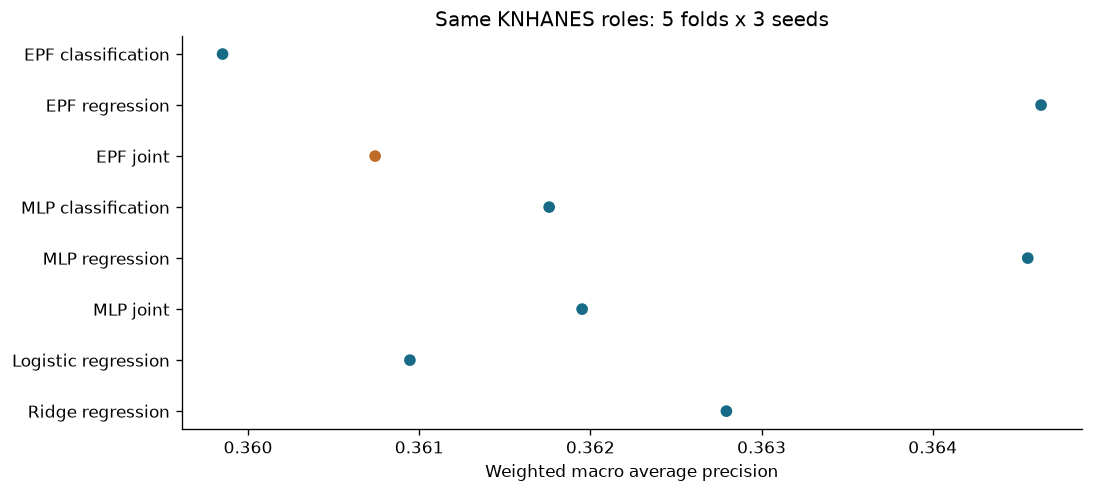

In [2]:
summary=pd.DataFrame([{ "model":N[k],"macro_AP":v["clean"]["macro_ap"],"Brier":v["clean"]["macro_brier"],"specificity_at_95_descriptive":v["descriptive_matched_sensitivity"]["0.95"]["specificity"],"numeric_NMSE":v.get("regression",{}).get("clean",{}).get("macro_NMSE")} for k,v in M.items()]).set_index("model")
display(summary.round(6))
fig,ax=plt.subplots(figsize=(9,4),layout="constrained")
ax.scatter(summary.macro_AP,summary.index,color=["#bf6c29" if k=="EPF joint" else "#176b87" for k in summary.index]);ax.invert_yaxis();ax.set_xlabel("Weighted macro average precision");ax.set_title("Same KNHANES roles: 5 folds x 3 seeds")
plt.show()

## 수치 예측 오차

TG 학습은 log1p 공간이지만 결과는 원 단위다. 서로 다른 단위의 MAE를 단순 평균하지 않는다. NMSE는 수치별 가중 분산으로 정규화한 MSE의 평균이다.

In [3]:
numeric=[]
for k,v in M.items():
    if "regression" in v:
        for row in v["regression"]["clean"]["per_target"]:numeric.append({"model":N[k],"target":T[row["target"]],**{a:row[a] for a in ["MAE","RMSE","NMSE","R2","near_MAE","near_n"]}})
numeric=pd.DataFrame(numeric)
display(numeric.pivot(index="target",columns="model",values="MAE").round(3))
display(numeric.pivot(index="target",columns="model",values="RMSE").round(3))

model,EPF joint,EPF regression,MLP joint,MLP regression,Ridge regression
target,,,,,
DBP (mmHg),6.002,5.993,5.993,5.982,5.982
Glucose (mg/dL),6.444,6.419,6.400,6.358,6.418
HDL (mg/dL),9.185,9.196,9.179,9.196,9.194
SBP (mmHg),6.960,6.957,6.947,6.947,6.921
TG (mg/dL),40.845,40.859,40.968,40.867,41.024


model,EPF joint,EPF regression,MLP joint,MLP regression,Ridge regression
target,,,,,
DBP (mmHg),7.767,7.754,7.756,7.754,7.744
Glucose (mg/dL),12.243,12.237,12.208,12.201,12.222
HDL (mg/dL),11.821,11.823,11.816,11.818,11.820
SBP (mmHg),9.078,9.066,9.062,9.064,9.039
TG (mg/dL),73.146,73.353,73.305,73.439,73.604


## 기준값 주변 오차

실제 검사값이 기준 근처인 사람을 비교한다. 폭은 혈당±10, SBP±10, DBP±5, TG±30, HDL±5로 사전 고정했다. 그림은 단위 차이를 제거하기 위해 EPF 수치 전용의 주변 MAE를 1로 놓은 비율이다.

model,EPF joint,EPF regression,MLP joint,MLP regression,Ridge regression
target,,,,,
DBP (mmHg),9.830,9.934,9.860,9.983,9.819
Glucose (mg/dL),5.256,5.209,5.187,5.185,5.154
HDL (mg/dL),9.120,9.210,9.096,9.221,9.214
SBP (mmHg),8.573,8.639,8.579,8.678,8.621
TG (mg/dL),39.303,39.575,39.273,39.654,39.348


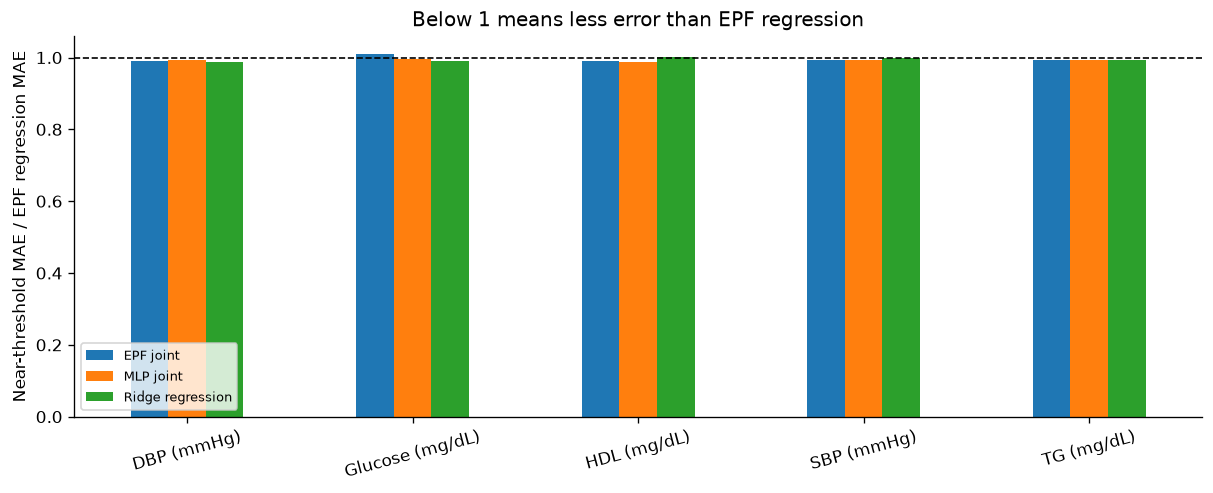

In [4]:
near=numeric.pivot(index="target",columns="model",values="near_MAE")
display(near.round(3))
ratio=near.div(near["EPF regression"],axis=0)
fig,ax=plt.subplots(figsize=(10,4),layout="constrained")
ratio[["EPF joint","MLP joint","Ridge regression"]].plot.bar(ax=ax);ax.axhline(1,color="black",ls="--",lw=1);ax.set_ylabel("Near-threshold MAE / EPF regression MAE");ax.set_xlabel("");ax.tick_params(axis="x",rotation=15);ax.legend(fontsize=8);ax.set_title("Below 1 means less error than EPF regression")
plt.show()

## 공동 학습의 선별 효과와 불확실성

고정된 OOF 예측에 대해 전체 조사 표본 틀의 PSU를 paired bootstrap했다. 구간은 재학습 전체 불확실성을 포함하지 않으며 다중 비교 보정을 하지 않았다. 기준 자료도 반복 탐색한 자료다.

,AP_difference_pp,low,high
reference,,,
EPF classification,0.0891,-0.2586,0.4258
EPF regression,-0.3891,-1.2520,0.4651
MLP joint,-0.1209,-0.4780,0.2551
Logistic regression,-0.0203,-0.8065,0.6909


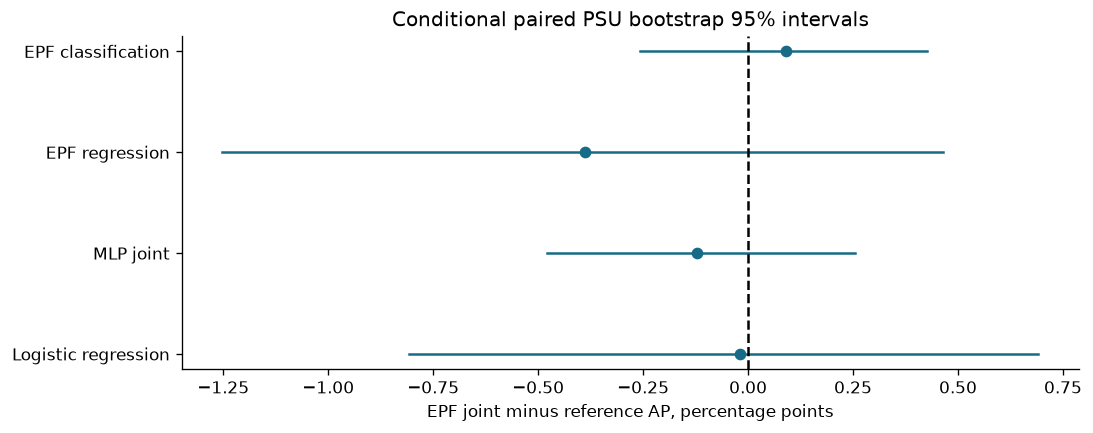

In [5]:
contrasts=pd.DataFrame([{ "reference":N[k],"AP_difference_pp":100*v["AP_difference"]["estimate"],"low":100*v["AP_difference"]["ci95"][0],"high":100*v["AP_difference"]["ci95"][1]} for k,v in R["contrasts"].items()]).set_index("reference")
display(contrasts.round(4))
fig,ax=plt.subplots(figsize=(9,3.5),layout="constrained")
for i,(name,row) in enumerate(contrasts.iterrows()):
    ax.plot([row.low,row.high],[i,i],color="#176b87");ax.scatter(row.AP_difference_pp,i,color="#176b87")
ax.set_yticks(range(len(contrasts)),contrasts.index);ax.invert_yaxis();ax.axvline(0,color="black",ls="--");ax.set_xlabel("EPF joint minus reference AP, percentage points");ax.set_title("Conditional paired PSU bootstrap 95% intervals")
plt.show()

## 실제 고정 컷오프의 검사 의뢰

별도 threshold 자료에서 개발 민감도90/95 목표로 컷오프를 정했다. 시험에서 달성한 민감도는 같지 않을 수 있다. 그림은 그 실제 운영점이며 시험 자료로 컷오프를 다시 고른 결과가 아니다.

,model,development_target,sensitivity,specificity,referral_rate
0,EPF classification,0.90,0.8722,0.4719,0.6588
1,EPF classification,0.95,0.9319,0.3220,0.7745
2,EPF regression,0.90,0.8656,0.4820,0.6500
3,EPF regression,0.95,0.9325,0.2942,0.7920
4,EPF joint,0.90,0.8720,0.4709,0.6594
5,EPF joint,0.95,0.9304,0.3220,0.7739
6,MLP classification,0.90,0.8724,0.4732,0.6581
7,MLP classification,0.95,0.9305,0.3269,0.7709
8,MLP regression,0.90,0.8633,0.4829,0.6486
9,MLP regression,0.95,0.9364,0.2795,0.8025


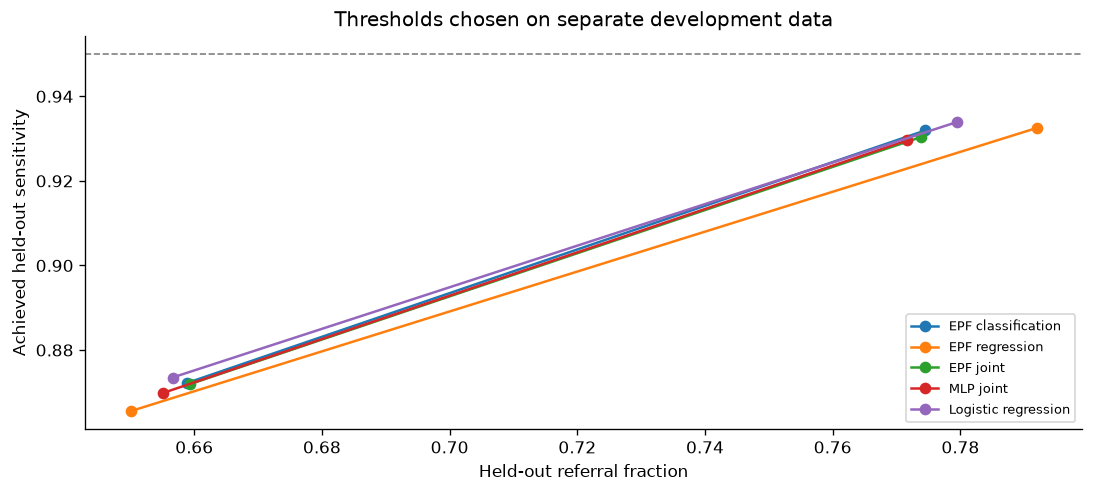

In [6]:
screen=pd.DataFrame([{ "model":N[k],"development_target":float(policy),**row} for k,v in M.items() for policy,row in v["screening"].items()])
display(screen.round(4))
fig,ax=plt.subplots(figsize=(9,4),layout="constrained")
for name in ["EPF classification","EPF regression","EPF joint","MLP joint","Logistic regression"]:
    a=screen[screen.model==name];ax.plot(a.referral_rate,a.sensitivity,"o-",label=name)
ax.axhline(.95,color="gray",ls="--",lw=1);ax.set_xlabel("Held-out referral fraction");ax.set_ylabel("Achieved held-out sensitivity");ax.legend(fontsize=8);ax.set_title("Thresholds chosen on separate development data")
plt.show()

## 학습·재현 확인

초기 선형 모델이 선택된 경우도 그대로 보고한다. 전체 파라미터 수에는 비활성 출력 행이 포함된다. 수치 오차 감소만으로 임상 선별 개선을 확정하지 않는다.

In [7]:
training=pd.DataFrame(R["training"])
display(training.groupby("name").agg(parameters=("parameters","first"),mean_fit_seconds=("fit_seconds","mean"),mean_epochs=("epochs","mean"),initial_model_selected=("best_epoch",lambda s:int((s==0).sum()))))
display(pd.Series({k:v for k,v in R["verification"].items() if k!="roles"},name="Reload verification"))

,parameters,mean_fit_seconds,mean_epochs,initial_model_selected
name,,,,
EPF_classification,9373,6.624668,34.666667,0
EPF_joint,9373,7.033961,36.466667,0
EPF_regression,9373,7.018530,36.333333,1
MLP_classification,9358,0.692364,34.866667,0
MLP_joint,9358,0.909710,39.866667,0
MLP_regression,9358,0.896446,43.333333,0


device                       cuda
source_hashes_matched        True
neural_model_instances         90
linear_procedures              30
model_view_evaluations       1560
probability_max_abs_error     0.0
measurement_max_abs_error       0
Name: Reload verification, dtype: object

EPF 공동 학습의 macro AP는 분류 전용 대비 +0.000891, LR 대비 -0.000203였다. 수치 macro NMSE의 개선량(수치 전용−공동)은 -0.000013였다. 수치 오차 감소와 선별 개선은 별개로 판단한다. 이번 비교에서는 공동 학습의 전반적인 개선이 확인되지 않아, LR 기준 모델을 유지하고 EPF 각 방식은 연구 후보로 남긴다.

입력은 비침습 변수만 유지했다. 네 이상 소견은 동시 발생할 수 있는 다중 라벨이며 확정 질환 진단이 아니다. 검사 수치 추정은 연구용 보조 출력이다. 2021–2024는 같은 사람을 추적한 시계열이 아니다.